In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import warnings
warnings.filterwarnings(action="ignore")

import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
import numpy as np

from matplotlib import pyplot as plt
from matplotlib.ticker import FixedLocator, FixedFormatter
import seaborn as sn

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.metrics import mean_squared_error
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import silhouette_score
from sklearn.metrics import silhouette_samples

In [ ]:
# Cargamos el dataset (en la carpeta data con nombre Regresion)
Japan1 = pd.read_excel('/content/drive/MyDrive/Proyecto Final Master/ModeloAnalitico2.xlsx')

In [ ]:
# Visualizar las 5 primeras muestras del dataset
Japan1.head(2)

,Indice,AA Player,Age,Club,Country,Position,Attacking,Creativity,Defending,Tactical,Technical,Rating,Goals_per_game,Shots_per_game,Touches,Accurate_per_game,Porcentaje_accurate,Interceptions_per_game,Tackles_per_game,%Total_duels_won,%Aerial_duels_won
0,1,Daichi Kamada,26,Eint Frankfurt,Alemania,MF,66.0,63.0,38.0,49.0,66.0,7.43,0.7,1.2,47.3,29.5,81,1.0,2.5,61,57
1,2,Kota Kudo,19,Fujieda MYFC,Japon,DF,NaN,NaN,NaN,NaN,NaN,7.40,0.0,1.0,75.0,59.0,89,1.0,1.0,75,67


In [ ]:
Japan1 = Japan1.drop(columns=['Indice'])

In [ ]:
Japan1.head(2)

,AA Player,Age,Club,Country,Position,Attacking,Creativity,Defending,Tactical,Technical,Rating,Goals_per_game,Shots_per_game,Touches,Accurate_per_game,Porcentaje_accurate,Interceptions_per_game,Tackles_per_game,%Total_duels_won,%Aerial_duels_won
0,Daichi Kamada,26,Eint Frankfurt,Alemania,MF,66.0,63.0,38.0,49.0,66.0,7.43,0.7,1.2,47.3,29.5,81,1.0,2.5,61,57
1,Kota Kudo,19,Fujieda MYFC,Japon,DF,NaN,NaN,NaN,NaN,NaN,7.40,0.0,1.0,75.0,59.0,89,1.0,1.0,75,67


In [ ]:
Japan1 = Japan1.rename(columns={'AA Player': 'Player'})
Japan1.head(2)

,Player,Age,Club,Country,Position,Attacking,Creativity,Defending,Tactical,Technical,Rating,Goals_per_game,Shots_per_game,Touches,Accurate_per_game,Porcentaje_accurate,Interceptions_per_game,Tackles_per_game,%Total_duels_won,%Aerial_duels_won
0,Daichi Kamada,26,Eint Frankfurt,Alemania,MF,66.0,63.0,38.0,49.0,66.0,7.43,0.7,1.2,47.3,29.5,81,1.0,2.5,61,57
1,Kota Kudo,19,Fujieda MYFC,Japon,DF,NaN,NaN,NaN,NaN,NaN,7.40,0.0,1.0,75.0,59.0,89,1.0,1.0,75,67


In [ ]:
# Visualizar los tipos de datos de cada variable
Japan1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107 entries, 0 to 106
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Player                  107 non-null    object 
 1   Age                     107 non-null    int64  
 2   Club                    107 non-null    object 
 3   Country                 107 non-null    object 
 4   Position                107 non-null    object 
 5   Attacking               58 non-null     float64
 6   Creativity              58 non-null     float64
 7   Defending               58 non-null     float64
 8   Tactical                58 non-null     float64
 9   Technical               58 non-null     float64
 10  Rating                  107 non-null    float64
 11  Goals_per_game          107 non-null    float64
 12  Shots_per_game          107 non-null    float64
 13  Touches                 107 non-null    float64
 14  Accurate_per_game       107 non-null    fl

In [ ]:
# Visualizar los parámetros estadísticos del dataset
Japan1.describe()

,Age,Attacking,Creativity,Defending,Tactical,Technical,Rating,Goals_per_game,Shots_per_game,Touches,Accurate_per_game,Porcentaje_accurate,Interceptions_per_game,Tackles_per_game,%Total_duels_won,%Aerial_duels_won
count,107.000000,58.000000,58.000000,58.000000,58.000000,58.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000
mean,22.943925,50.724138,50.327586,50.913793,46.431034,50.155172,6.777757,0.097196,0.770093,39.825234,22.205607,75.915888,0.709346,1.100000,47.411215,41.757009
std,3.620778,11.291657,8.163651,14.611080,9.652037,5.943600,0.257507,0.157491,0.689984,22.617338,16.854263,15.187583,0.678863,0.781146,15.578137,23.001986
min,17.000000,32.000000,37.000000,20.000000,27.000000,35.000000,6.050000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,21.000000,42.000000,44.000000,38.250000,39.750000,46.000000,6.600000,0.000000,0.300000,20.500000,9.650000,73.000000,0.200000,0.600000,41.500000,30.000000
50%,22.000000,50.000000,50.000000,52.000000,47.500000,50.000000,6.760000,0.000000,0.700000,37.800000,18.100000,79.000000,0.600000,1.000000,50.000000,42.000000
75%,25.000000,59.000000,55.750000,61.750000,53.000000,53.750000,6.970000,0.100000,1.050000,58.800000,31.750000,83.000000,1.000000,1.450000,56.000000,57.500000
max,36.000000,71.000000,76.000000,79.000000,70.000000,66.000000,7.430000,0.800000,3.300000,91.800000,75.800000,100.000000,4.000000,5.000000,100.000000,100.000000


array([[<Axes: title={'center': 'Attacking'}>]], dtype=object)

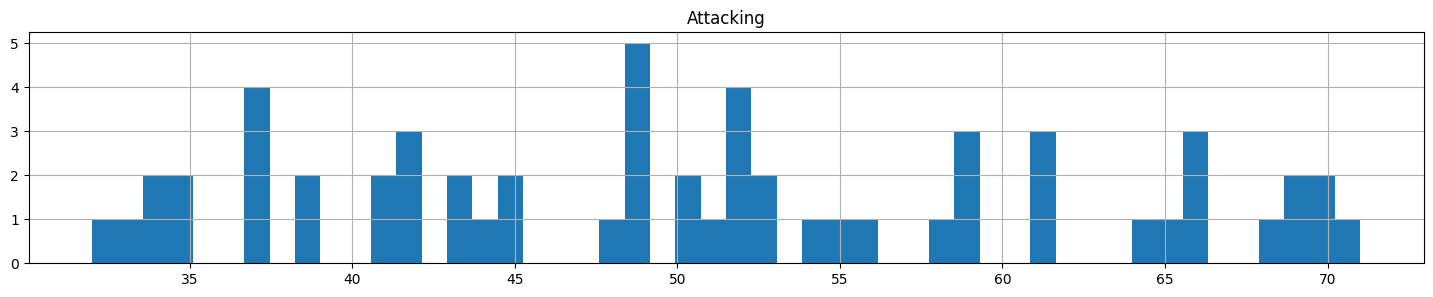

In [ ]:
#Visualizar los histogramas del dataset
Japan1.hist(column=('Attacking') , bins=50, figsize=(18,3) )

In [ ]:
# Cargamos el dataset (en la carpeta data con nombre Clustering)
#Japan1
#Japan2

In [ ]:
# Visualizar las 5 primeras muestras del dataset
#Japan2.head()

In [ ]:
Japan1 = Japan1.fillna(0)

In [ ]:
J1 = Japan1[['Player','Age','Club' ,'Country' ,'Position','Goals_per_game','Shots_per_game','Touches','Accurate_per_game',
            'Porcentaje_accurate','Interceptions_per_game','Tackles_per_game',
            '%Total_duels_won','%Aerial_duels_won']]

In [ ]:
J1.head(5)

,Player,Age,Club,Country,Position,Goals_per_game,Shots_per_game,Touches,Accurate_per_game,Porcentaje_accurate,Interceptions_per_game,Tackles_per_game,%Total_duels_won,%Aerial_duels_won
0,Daichi Kamada,26,Eint Frankfurt,Alemania,MF,0.7,1.2,47.3,29.5,81,1.0,2.5,61,57
1,Kota Kudo,19,Fujieda MYFC,Japon,DF,0.0,1.0,75.0,59.0,89,1.0,1.0,75,67
2,Atsuki Ito,24,Urawa Reds,Japon,MF,0.1,1.2,60.1,38.1,84,1.2,2.9,61,65
3,Nagi Matsumoto,21,Ventforet Kofu,Japon,MF,0.0,0.0,49.0,21.0,72,3.0,5.0,64,50
4,Shuto Machino,23,Shonan Bellmare,Japon,FW,0.5,3.3,44.0,19.8,71,0.2,0.4,38,40


In [ ]:
# Visualizar los tipos de datos de cada variable
J1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107 entries, 0 to 106
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Player                  107 non-null    object 
 1   Age                     107 non-null    int64  
 2   Club                    107 non-null    object 
 3   Country                 107 non-null    object 
 4   Position                107 non-null    object 
 5   Goals_per_game          107 non-null    float64
 6   Shots_per_game          107 non-null    float64
 7   Touches                 107 non-null    float64
 8   Accurate_per_game       107 non-null    float64
 9   Porcentaje_accurate     107 non-null    int64  
 10  Interceptions_per_game  107 non-null    float64
 11  Tackles_per_game        107 non-null    float64
 12  %Total_duels_won        107 non-null    int64  
 13  %Aerial_duels_won       107 non-null    int64  
dtypes: float64(6), int64(4), object(4)
memory 

In [ ]:
DelanterosJap = J1.loc[J1['Position']=='FW']
MediocampoJap = J1.loc[J1['Position']=='MF']
DefensaJap = J1.loc[J1['Position']=='DF']

In [ ]:
DelanterosJap.head(2)

,Player,Age,Club,Country,Position,Goals_per_game,Shots_per_game,Touches,Accurate_per_game,Porcentaje_accurate,Interceptions_per_game,Tackles_per_game,%Total_duels_won,%Aerial_duels_won
4,Shuto Machino,23,Shonan Bellmare,Japon,FW,0.5,3.3,44.0,19.8,71,0.2,0.4,38,40
11,Kyogo Furuhashi,28,Celtic,Escocia,FW,0.8,2.4,13.3,4.1,68,0.1,0.4,36,13


In [ ]:
MediocampoJap.head(2)

,Player,Age,Club,Country,Position,Goals_per_game,Shots_per_game,Touches,Accurate_per_game,Porcentaje_accurate,Interceptions_per_game,Tackles_per_game,%Total_duels_won,%Aerial_duels_won
0,Daichi Kamada,26,Eint Frankfurt,Alemania,MF,0.7,1.2,47.3,29.5,81,1.0,2.5,61,57
2,Atsuki Ito,24,Urawa Reds,Japon,MF,0.1,1.2,60.1,38.1,84,1.2,2.9,61,65


In [ ]:
DefensaJap.head(2)

,Player,Age,Club,Country,Position,Goals_per_game,Shots_per_game,Touches,Accurate_per_game,Porcentaje_accurate,Interceptions_per_game,Tackles_per_game,%Total_duels_won,%Aerial_duels_won
1,Kota Kudo,19,Fujieda MYFC,Japon,DF,0.0,1.0,75.0,59.0,89,1.0,1.0,75,67
5,Shogo Taniguchi,31,Kawa Frontale,Japon,DF,0.0,0.0,70.2,57.2,91,0.7,0.8,64,42


In [ ]:
J3 = Japan1[['Goals_per_game','Shots_per_game','Touches','Accurate_per_game',
            'Porcentaje_accurate','Interceptions_per_game','Tackles_per_game',
            '%Total_duels_won','%Aerial_duels_won']]

In [ ]:
#Normalizar los valores caracteristicos de J2
J3 = (J3 - J3.min()) / (J3.max() - J3.min())

In [ ]:
J3.describe()

,Goals_per_game,Shots_per_game,Touches,Accurate_per_game,Porcentaje_accurate,Interceptions_per_game,Tackles_per_game,%Total_duels_won,%Aerial_duels_won
count,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.00000
mean,0.121495,0.233362,0.421216,0.292950,0.759159,0.177336,0.220000,0.474112,0.41757
std,0.196864,0.209086,0.251863,0.222352,0.151876,0.169716,0.156229,0.155781,0.23002
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,0.000000,0.090909,0.206013,0.127309,0.730000,0.050000,0.120000,0.415000,0.30000
50%,0.000000,0.212121,0.398664,0.238786,0.790000,0.150000,0.200000,0.500000,0.42000
75%,0.125000,0.318182,0.632517,0.418865,0.830000,0.250000,0.290000,0.560000,0.57500
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [ ]:
DelanterosJap.sort_values('Goals_per_game')

,Player,Age,Club,Country,Position,Goals_per_game,Shots_per_game,Touches,Accurate_per_game,Porcentaje_accurate,Interceptions_per_game,Tackles_per_game,%Total_duels_won,%Aerial_duels_won
105,Yusei Yashiki,19,Oita Trinita,Japon,FW,0.0,0.0,2.0,0.0,0,0.0,0.0,0,0
97,Shun Ayukawa,21,Sanfrecce Hiroshima,Japon,FW,0.0,0.3,9.3,6.0,86,0.0,0.0,60,100
96,Itsuki Someno,21,Kashima Antlers,Japon,FW,0.0,0.5,12.5,4.0,55,0.0,0.8,50,62
94,Yugo Masukake,19,Kashiwa Reysol,Japon,FW,0.0,0.4,6.4,2.2,69,0.0,0.0,31,17
93,Naoki Kumata,18,FC Tokyo,Japon,FW,0.0,0.0,3.0,2.0,100,0.0,0.0,100,0
91,Yudai Kimura,21,Kyoto Sanga FC,Japon,FW,0.0,0.9,14.4,4.6,80,0.0,0.4,43,25
35,Hiroki Abe,24,Barcelona Atletic,España,FW,0.0,0.3,29.3,16.5,79,0.2,1.0,70,33
84,Jun Nishikawa,21,Sagan Tosu,Japon,FW,0.0,0.4,18.6,8.0,76,0.1,1.1,40,33
82,Shio Fukuda,19,Borussia Monchengladbach II,Alemania,FW,0.0,0.0,5.3,1.7,63,0.0,0.7,43,29
77,Kazunari Ichimi,25,Kyoto Sanga FC,Japon,FW,0.0,0.9,20.7,8.2,72,0.1,0.5,44,40


In [ ]:
# Escalar las variables Gol/Sh y npxG/Sh
# Recomendación: como hacemos en el notebook, crea unas variables (std) y luego escala.
#DelanterosJap['Goals_per_game_std'] = DelanterosJap['Goals_per_game']
#DelanterosJap['Shots_per_game_std'] = DelanterosJap['Shots_per_game']

#DelanterosJap[['Goals_per_game_std', 'Shots_per_game_std']] = StandardScaler().fit_transform(DelanterosJap[['Goals_per_game', 'Shots_per_game']])

In [ ]:
# Visualizamos los datos
#A = DelanterosJap[['Goals_per_game_std', 'Shots_per_game_std']].values
#plt.figure(figsize=(20, 20))
#plt.scatter(A[:, 0], A[:, 1], c=None, s=50)
#plt.xlabel("Goles por Partido", fontsize=14)
#plt.ylabel("Disparos por Partido", fontsize=14, rotation=0)
#plt.show()

In [ ]:
J3['DatosA'] = ((J3['Goals_per_game']+J3['Shots_per_game']+
                J3['Touches']+J3['Accurate_per_game']+
                J3['Porcentaje_accurate']) / 5)
J3['DatosB'] = ((J3['Interceptions_per_game']+J3['Tackles_per_game']+
                J3['%Total_duels_won']+J3['%Aerial_duels_won']) / 4)

In [ ]:
J3.head(2)

,Goals_per_game,Shots_per_game,Touches,Accurate_per_game,Porcentaje_accurate,Interceptions_per_game,Tackles_per_game,%Total_duels_won,%Aerial_duels_won,DatosA,DatosB
0,0.875,0.363636,0.504454,0.389182,0.81,0.25,0.5,0.61,0.57,0.588455,0.4825
1,0.000,0.303030,0.812918,0.778364,0.89,0.25,0.2,0.75,0.67,0.556862,0.4675


In [ ]:
J1['DatosA'] = J3['DatosA']
J1['DatosB'] = J3['DatosB']

In [ ]:
DelanterosJap['DatosA'] = J3['DatosA']
DelanterosJap['DatosB'] = J3['DatosB']

In [ ]:
MediocampoJap['DatosA'] = J3['DatosA']
MediocampoJap['DatosB'] = J3['DatosB']

In [ ]:
DefensaJap['DatosA'] = J3['DatosA']
DefensaJap['DatosB'] = J3['DatosB']

In [ ]:
J1.head(2)

,Player,Age,Club,Country,Position,Goals_per_game,Shots_per_game,Touches,Accurate_per_game,Porcentaje_accurate,Interceptions_per_game,Tackles_per_game,%Total_duels_won,%Aerial_duels_won,DatosA,DatosB
0,Daichi Kamada,26,Eint Frankfurt,Alemania,MF,0.7,1.2,47.3,29.5,81,1.0,2.5,61,57,0.588455,0.4825
1,Kota Kudo,19,Fujieda MYFC,Japon,DF,0.0,1.0,75.0,59.0,89,1.0,1.0,75,67,0.556862,0.4675


In [ ]:
MediocampoJap.head(2)

,Player,Age,Club,Country,Position,Goals_per_game,Shots_per_game,Touches,Accurate_per_game,Porcentaje_accurate,Interceptions_per_game,Tackles_per_game,%Total_duels_won,%Aerial_duels_won,DatosA,DatosB
0,Daichi Kamada,26,Eint Frankfurt,Alemania,MF,0.7,1.2,47.3,29.5,81,1.0,2.5,61,57,0.588455,0.4825
2,Atsuki Ito,24,Urawa Reds,Japon,MF,0.1,1.2,60.1,38.1,84,1.2,2.9,61,65,0.495654,0.5350


In [ ]:
DelanterosJap.sort_values(['DatosA']).head(3)

,Player,Age,Club,Country,Position,Goals_per_game,Shots_per_game,Touches,Accurate_per_game,Porcentaje_accurate,Interceptions_per_game,Tackles_per_game,%Total_duels_won,%Aerial_duels_won,DatosA,DatosB
105,Yusei Yashiki,19,Oita Trinita,Japon,FW,0.0,0.0,2.0,0.0,0,0.0,0.0,0,0,0.000000,0.000
102,Shota Fujio,21,Machida Zelvia,Japon,FW,0.0,0.0,2.0,0.0,0,0.0,0.0,0,0,0.000000,0.000
82,Shio Fukuda,19,Borussia Monchengladbach II,Alemania,FW,0.0,0.0,5.3,1.7,63,0.0,0.7,43,29,0.137835,0.215


In [ ]:
DelanterosJap.drop(DelanterosJap[(DelanterosJap['DatosA'] == 0)].index, inplace=True)
DelanterosJap.sort_values(['DatosA']).head()

,Player,Age,Club,Country,Position,Goals_per_game,Shots_per_game,Touches,Accurate_per_game,Porcentaje_accurate,Interceptions_per_game,Tackles_per_game,%Total_duels_won,%Aerial_duels_won,DatosA,DatosB
82,Shio Fukuda,19,Borussia Monchengladbach II,Alemania,FW,0.0,0.0,5.3,1.7,63,0.0,0.7,43,29,0.137835,0.215
96,Itsuki Someno,21,Kashima Antlers,Japon,FW,0.0,0.5,12.5,4.0,55,0.0,0.8,50,62,0.174242,0.320
94,Yugo Masukake,19,Kashiwa Reysol,Japon,FW,0.0,0.4,6.4,2.2,69,0.0,0.0,31,17,0.177847,0.120
93,Naoki Kumata,18,FC Tokyo,Japon,FW,0.0,0.0,3.0,2.0,100,0.0,0.0,100,0,0.207504,0.250
97,Shun Ayukawa,21,Sanfrecce Hiroshima,Japon,FW,0.0,0.3,9.3,6.0,86,0.0,0.0,60,100,0.222271,0.400


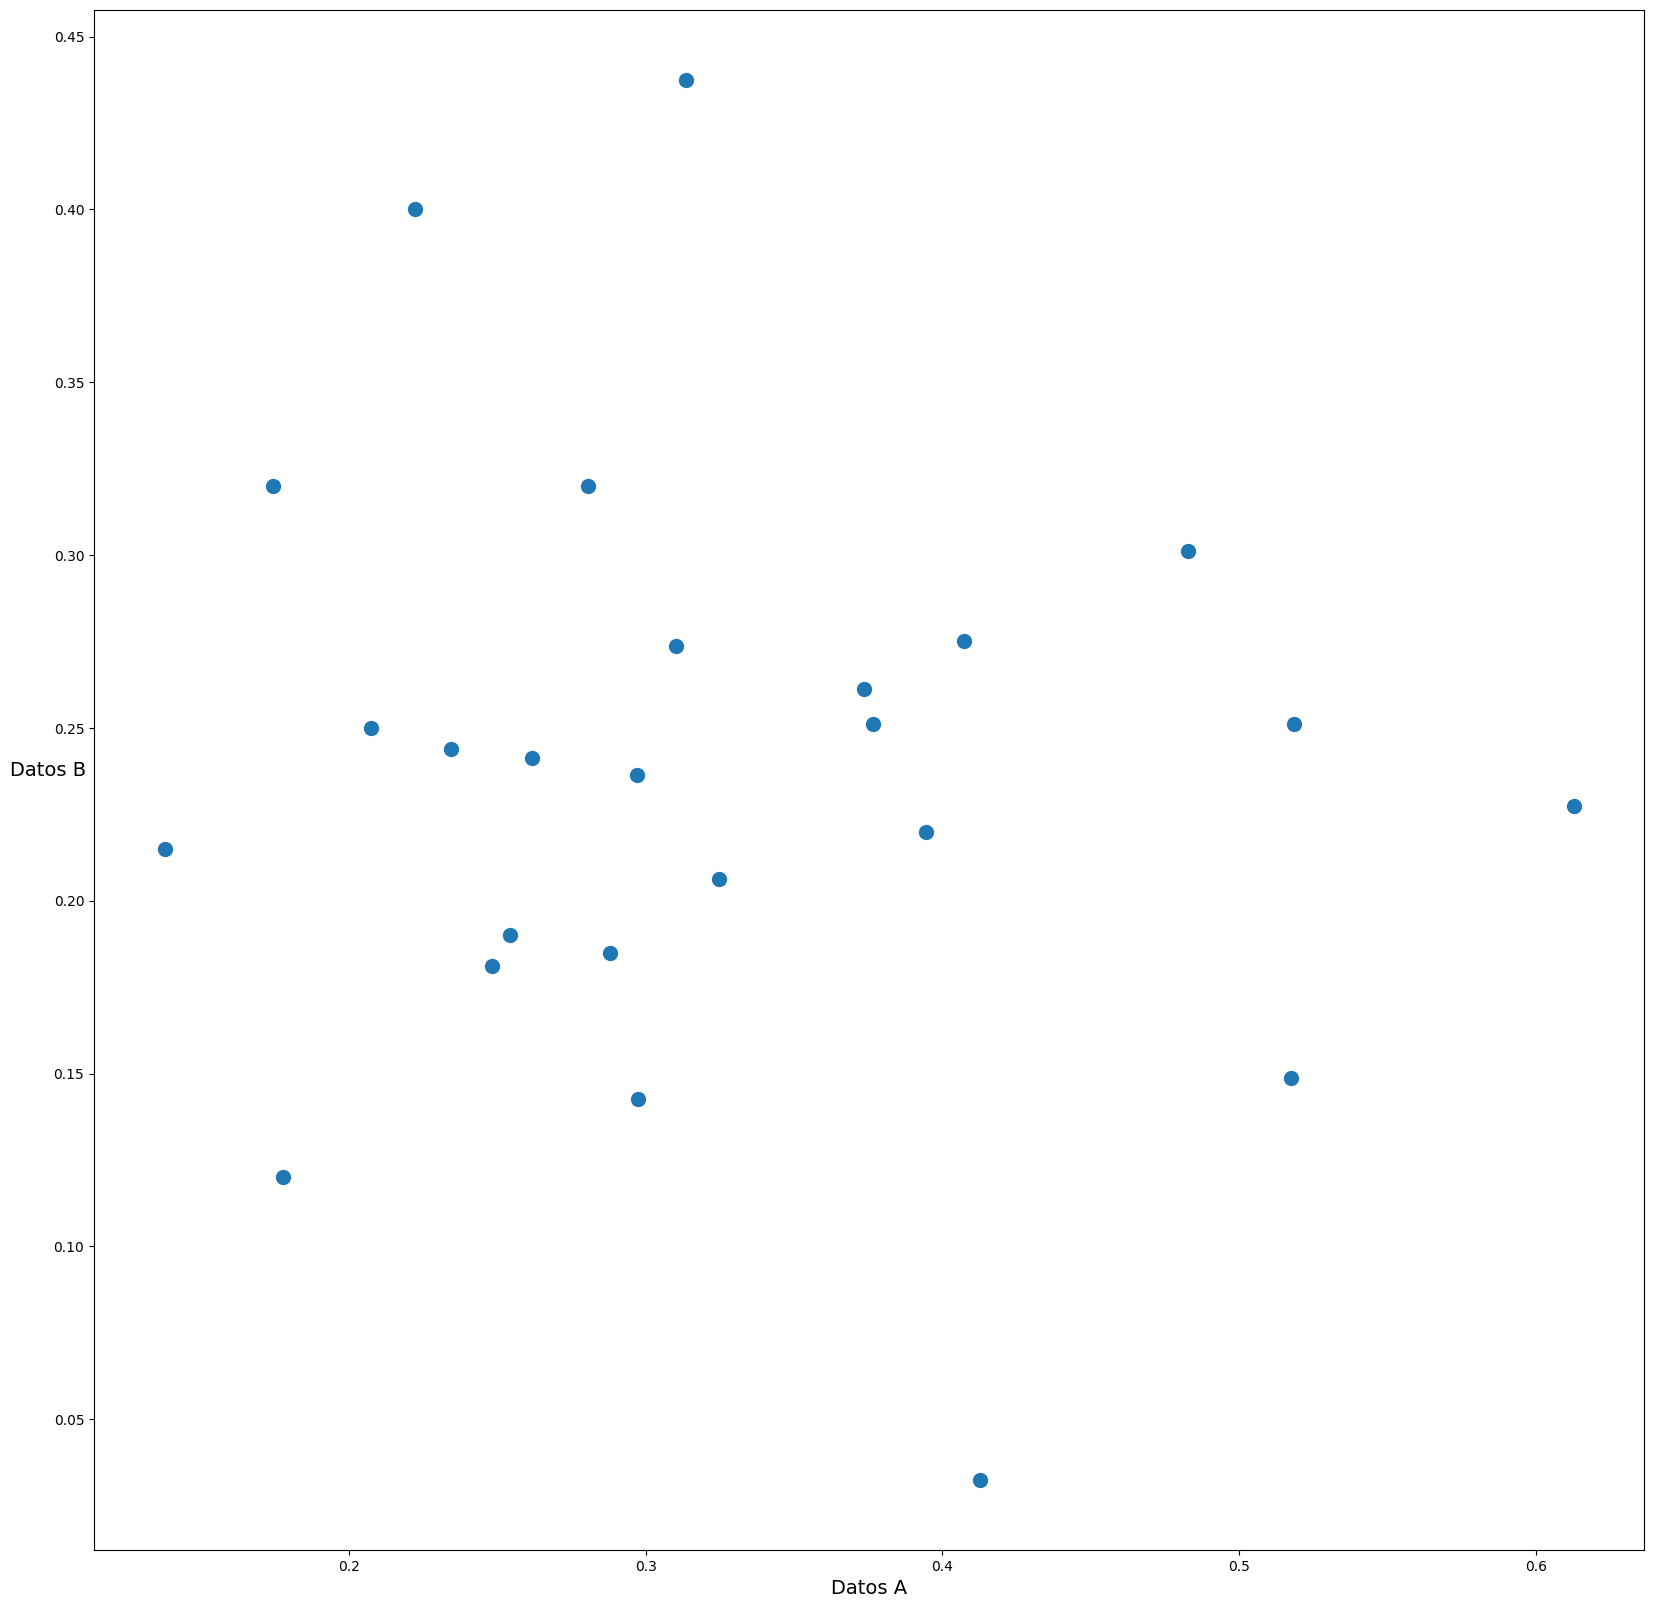

In [ ]:
# Visualizamos los datos
B = DelanterosJap[['DatosA', 'DatosB']].values
plt.figure(figsize=(20, 20))
plt.scatter(B[:, 0], B[:, 1], c=None, s=100)
plt.xlabel("Datos A", fontsize=14)
plt.ylabel("Datos B", fontsize=14, rotation=0)
plt.show()

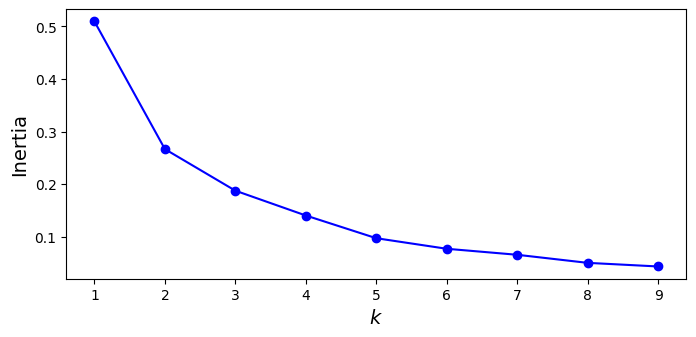

In [ ]:
# Visualizamos la inercia
kmeans_per_k = [KMeans(n_clusters=k, random_state=42).fit(B)
                for k in range(1, 10)]
inertias = [model.inertia_ for model in kmeans_per_k]

plt.figure(figsize=(8, 3.5))
plt.plot(range(1, 10), inertias, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Inertia", fontsize=14)

plt.show()

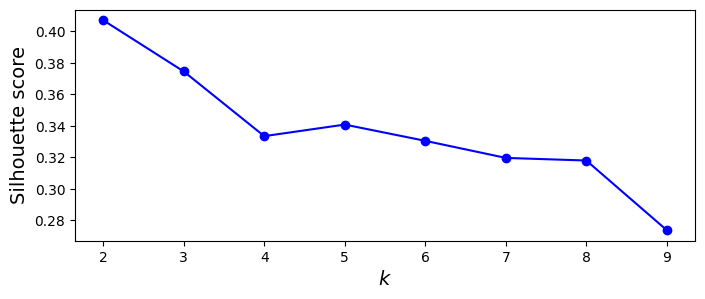

In [ ]:
# Visualizamos el sillhoute score
silhouette_scores = [silhouette_score(B, model.labels_) for model in kmeans_per_k[1:]]

plt.figure(figsize=(8, 3))
plt.plot(range(2, 10), silhouette_scores, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Silhouette score", fontsize=14)

plt.show()

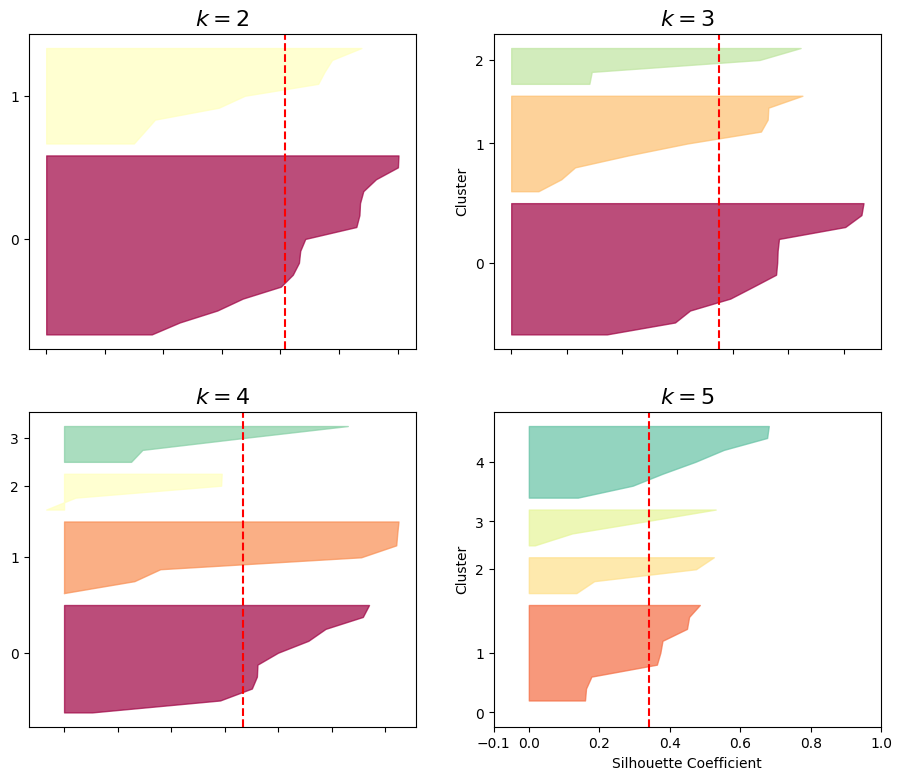

In [ ]:
# Pruebo el metodo de visualizacion de clusteres para sacarme la duda entre K = 2, K = 3, K = 5
plt.figure(figsize=(11, 9))

for k in (2, 3, 4, 5):
    plt.subplot(2, 2, k - 1)

    y_pred = kmeans_per_k[k - 1].labels_
    silhouette_coefficients = silhouette_samples(B, y_pred)

    padding = len(B) // 30
    pos = padding
    ticks = []
    for i in range(k):
        coeffs = silhouette_coefficients[y_pred == i]
        coeffs.sort()

        color = plt.cm.Spectral(i / k)
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))
    if k in (3, 5):
        plt.ylabel("Cluster")

    if k in (5, 6):
        plt.gca().set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
        plt.xlabel("Silhouette Coefficient")
    else:
        plt.tick_params(labelbottom=False)

    plt.axvline(x=silhouette_scores[k - 2], color="red", linestyle="--")
    plt.title("$k={}$".format(k), fontsize=16)

plt.show()

In [ ]:
# Dejar así
def Exec_KMeans(k, X):

    kmeans = KMeans(n_clusters=k, random_state=42)
    y_pred = kmeans.fit_predict(X)

    print("Centros de los clusters: ", kmeans.cluster_centers_)

    plt.figure(figsize=(16, 6))
    cl = ['red', 'green', 'blue', 'yellow', 'black']
    assign = []
    for row in y_pred:
        assign.append(cl[row])

    plt.scatter(X[:,0], X[:,1], c=assign, s=70 )

    plt.show()

    return y_pred

Centros de los clusters:  [[0.25325525 0.20708333]
 [0.45513982 0.21875   ]
 [0.24761952 0.369375  ]]


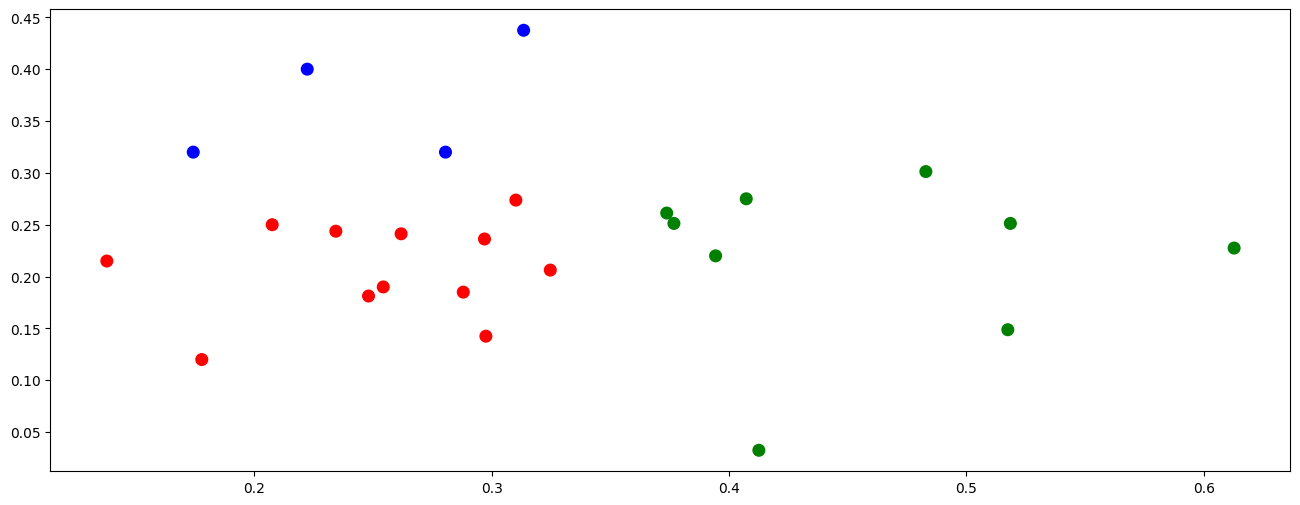

In [ ]:
K = 3
y_pred = Exec_KMeans(K, B)

Centros de los clusters:  [[0.25325525 0.20708333]
 [0.45513982 0.21875   ]
 [0.24761952 0.369375  ]]


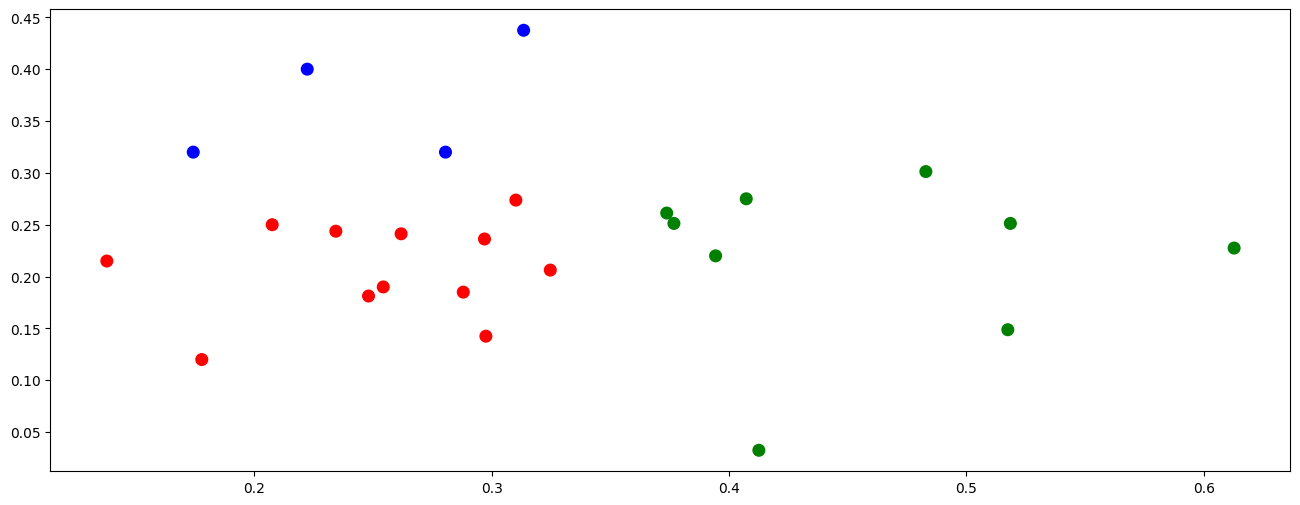

,Player,Age,Club,Country,Position,Goals_per_game,Shots_per_game,Touches,Accurate_per_game,Porcentaje_accurate,Interceptions_per_game,Tackles_per_game,%Total_duels_won,%Aerial_duels_won,DatosA,DatosB,Cluster
4,Shuto Machino,23,Shonan Bellmare,Japon,FW,0.5,3.3,44.0,19.8,71,0.2,0.4,38,40,0.612784,0.22750,1
11,Kyogo Furuhashi,28,Celtic,Escocia,FW,0.8,2.4,13.3,4.1,68,0.1,0.4,36,13,0.517440,0.14875,1
14,Ayase Ueda,24,Cercle Brugge,Belgica,FW,0.6,2.7,28.5,9.8,60,0.1,0.4,42,48,0.518514,0.25125,1
15,Takefusa Kubo,22,Real Sociedad,España,FW,0.3,2.1,39.5,17.1,76,0.3,1.3,48,39,0.482910,0.30125,1
26,Sota Kitano,18,Cerezo Osaka,Japon,FW,0.3,0.8,11.3,4.3,71,0.8,0.5,27,0,0.297543,0.14250,0
34,Yuito Suzuki,21,Strasbourg,Francia,FW,0.3,0.7,9.3,3.7,85,0.0,0.0,75,100,0.313445,0.43750,2
35,Hiroki Abe,24,Barcelona Atletic,España,FW,0.0,0.3,29.3,16.5,79,0.2,1.0,70,33,0.280519,0.32000,2
43,Yutaro Oda,21,Heart of Midlothian,Escocia,FW,0.1,1.1,18.6,7.7,74,0.3,0.9,47,22,0.296954,0.23625,0
45,Ritsu Doan,24,Freiburg,Alemania,FW,0.2,1.7,36.2,12.9,72,0.4,1.8,45,19,0.407237,0.27500,1
52,Daizen Maeda,25,Celtic,Escocia,FW,0.2,1.1,30.9,14.3,79,0.5,1.0,40,28,0.376763,0.25125,1


In [ ]:
# Ejecutamos KMeans con el número de clusters (K) que hayas elegido y guardalo en una variable 'Cluster'
# en el dataset original (dt, si es tu caso)
Kseleccionado = 3
DelanterosJap['Cluster'] = Exec_KMeans(Kseleccionado, B)
#plt.savefig('B.png', transparent=True)
DelanterosJap.head(30)

In [ ]:
DelanterosJap.to_excel("/content/drive/MyDrive/Proyecto Final Master/DELjap.xlsx",sheet_name='DELjap')

In [ ]:
J1.sort_values(['DatosA']).head(5)

,Player,Age,Club,Country,Position,Goals_per_game,Shots_per_game,Touches,Accurate_per_game,Porcentaje_accurate,Interceptions_per_game,Tackles_per_game,%Total_duels_won,%Aerial_duels_won,DatosA,DatosB
101,Riku Ochiai,24,Kashiwa Reysol,Japon,MF,0.0,0.0,2.0,0.0,0,0.0,0.0,0,0,0.000000,0.0000
102,Shota Fujio,21,Machida Zelvia,Japon,FW,0.0,0.0,2.0,0.0,0,0.0,0.0,0,0,0.000000,0.0000
105,Yusei Yashiki,19,Oita Trinita,Japon,FW,0.0,0.0,2.0,0.0,0,0.0,0.0,0,0,0.000000,0.0000
82,Shio Fukuda,19,Borussia Monchengladbach II,Alemania,FW,0.0,0.0,5.3,1.7,63,0.0,0.7,43,29,0.137835,0.2150
106,Hayate Matsuda,19,Mito Hollyhock,Japon,DF,0.0,0.3,15.3,2.7,53,0.0,0.3,46,75,0.160927,0.3175


In [ ]:
J1.drop(J1[(J1['DatosA'] == 0)].index, inplace=True)

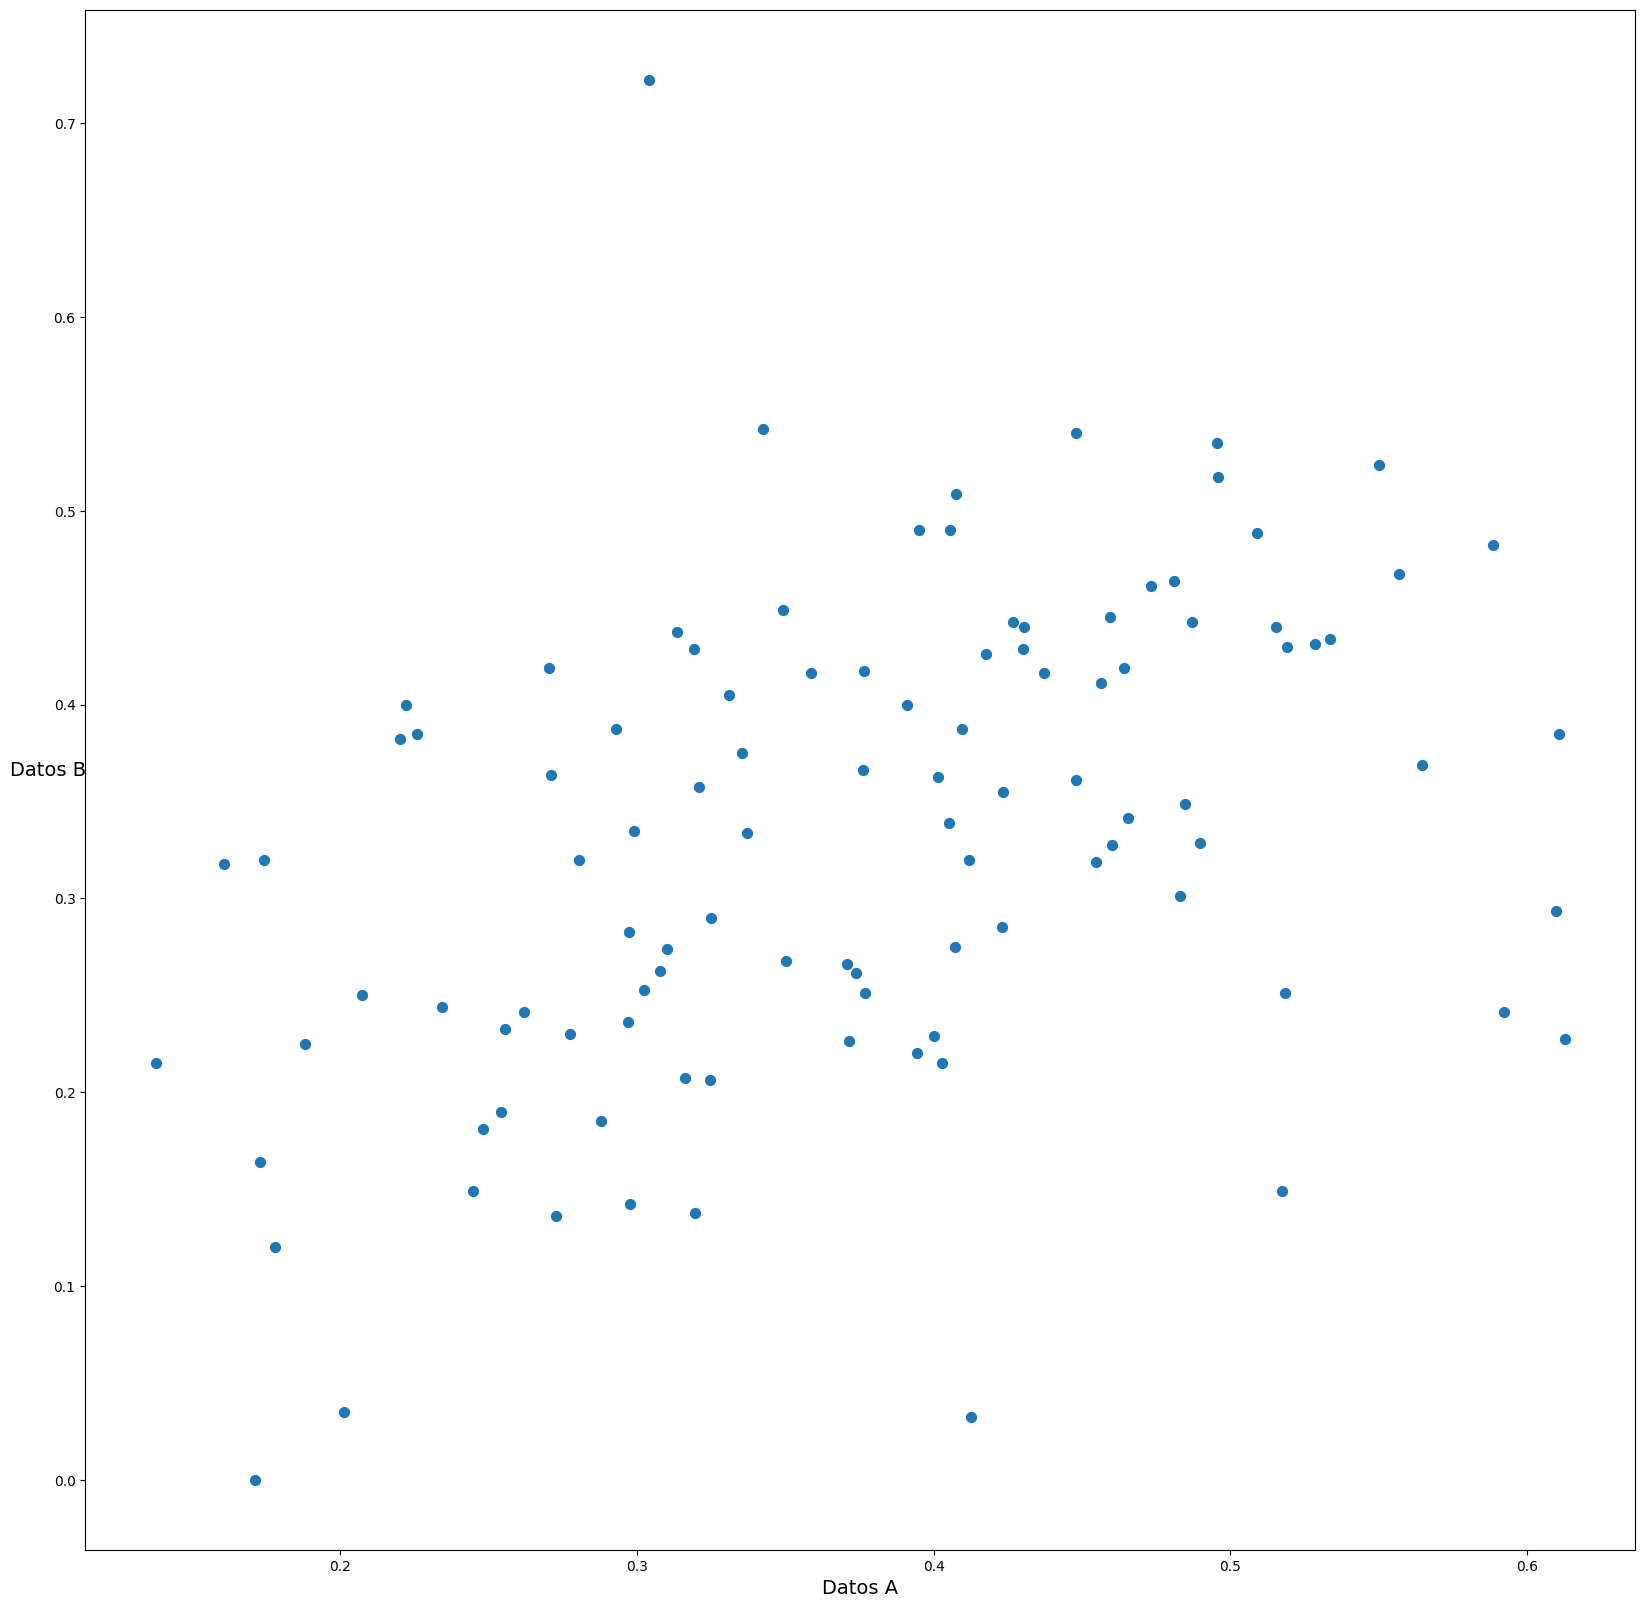

In [ ]:
# Visualizamos los datos
A = J1[['DatosA', 'DatosB']].values
plt.figure(figsize=(20, 20))
plt.scatter(A[:, 0], A[:, 1], c=None, s=50)
plt.xlabel("Datos A", fontsize=14)
plt.ylabel("Datos B", fontsize=14, rotation=0)
plt.show()

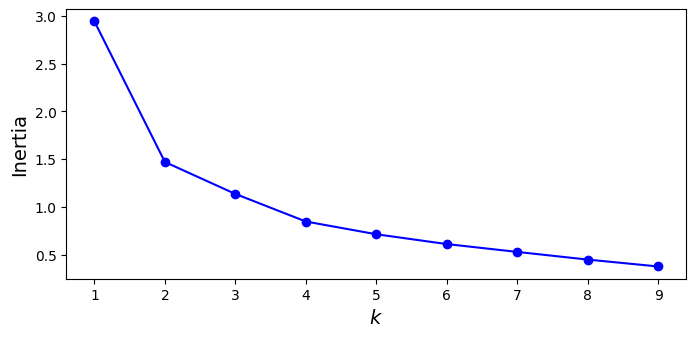

In [ ]:
# Visualizamos la inercia
kmeans_per_k = [KMeans(n_clusters=k, random_state=42).fit(A)
                for k in range(1, 10)]
inertias = [model.inertia_ for model in kmeans_per_k]

plt.figure(figsize=(8, 3.5))
plt.plot(range(1, 10), inertias, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Inertia", fontsize=14)

plt.show()

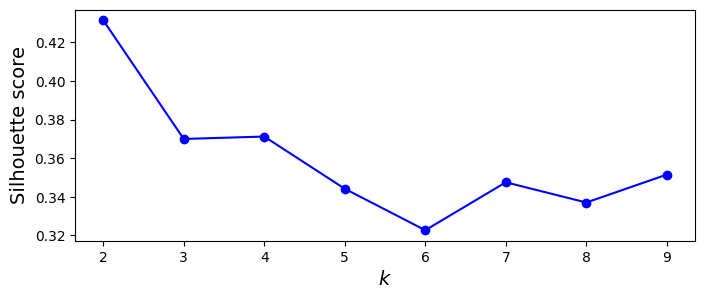

In [ ]:
# Visualizamos el sillhoute score
silhouette_scores = [silhouette_score(A, model.labels_) for model in kmeans_per_k[1:]]

plt.figure(figsize=(8, 3))
plt.plot(range(2, 10), silhouette_scores, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Silhouette score", fontsize=14)

plt.show()

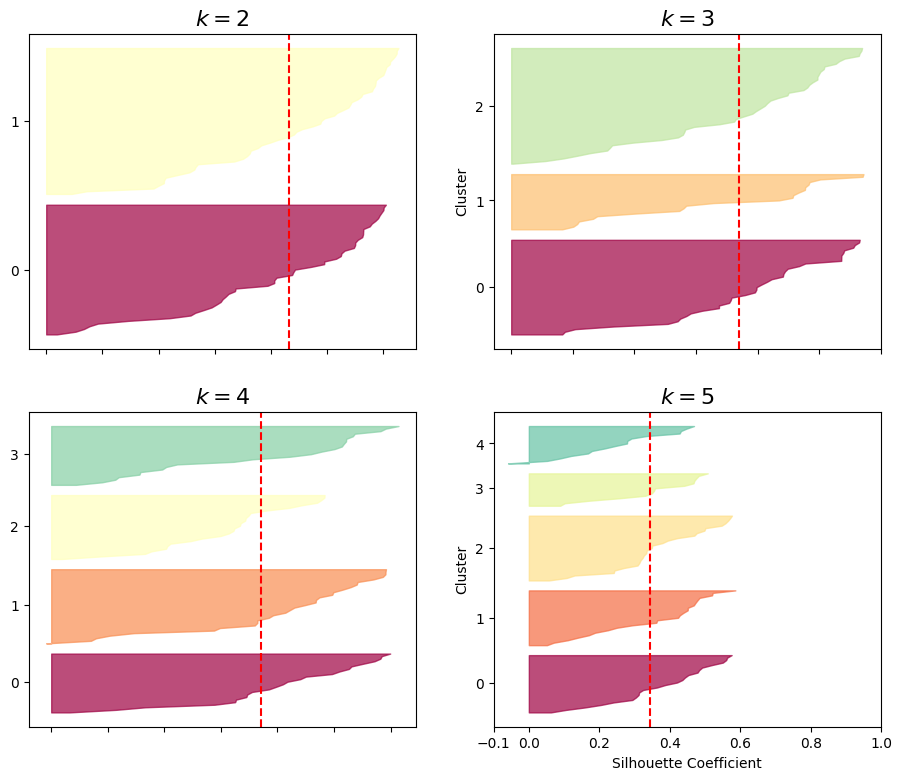

In [ ]:
# Pruebo el metodo de visualizacion de clusteres para sacarme la duda entre K = 2, K = 3, K = 5
plt.figure(figsize=(11, 9))

for k in (2, 3, 4, 5):
    plt.subplot(2, 2, k - 1)

    y_pred = kmeans_per_k[k - 1].labels_
    silhouette_coefficients = silhouette_samples(A, y_pred)

    padding = len(A) // 30
    pos = padding
    ticks = []
    for i in range(k):
        coeffs = silhouette_coefficients[y_pred == i]
        coeffs.sort()

        color = plt.cm.Spectral(i / k)
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))
    if k in (3, 5):
        plt.ylabel("Cluster")

    if k in (5, 6):
        plt.gca().set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
        plt.xlabel("Silhouette Coefficient")
    else:
        plt.tick_params(labelbottom=False)

    plt.axvline(x=silhouette_scores[k - 2], color="red", linestyle="--")
    plt.title("$k={}$".format(k), fontsize=16)

plt.show()

In [ ]:
# Dejar así
def Exec_KMeans(k, X):

    kmeans = KMeans(n_clusters=k, random_state=42)
    y_pred = kmeans.fit_predict(X)

    print("Centros de los clusters: ", kmeans.cluster_centers_)

    plt.figure(figsize=(16, 6))
    cl = ['red', 'green', 'blue', 'yellow', 'black']
    assign = []
    for row in y_pred:
        assign.append(cl[row])

    plt.scatter(X[:,0], X[:,1], c=assign, s=70)

    plt.show()

    return y_pred

Centros de los clusters:  [[0.29916078 0.20219595]
 [0.29463219 0.40369318]
 [0.47938317 0.40263889]]


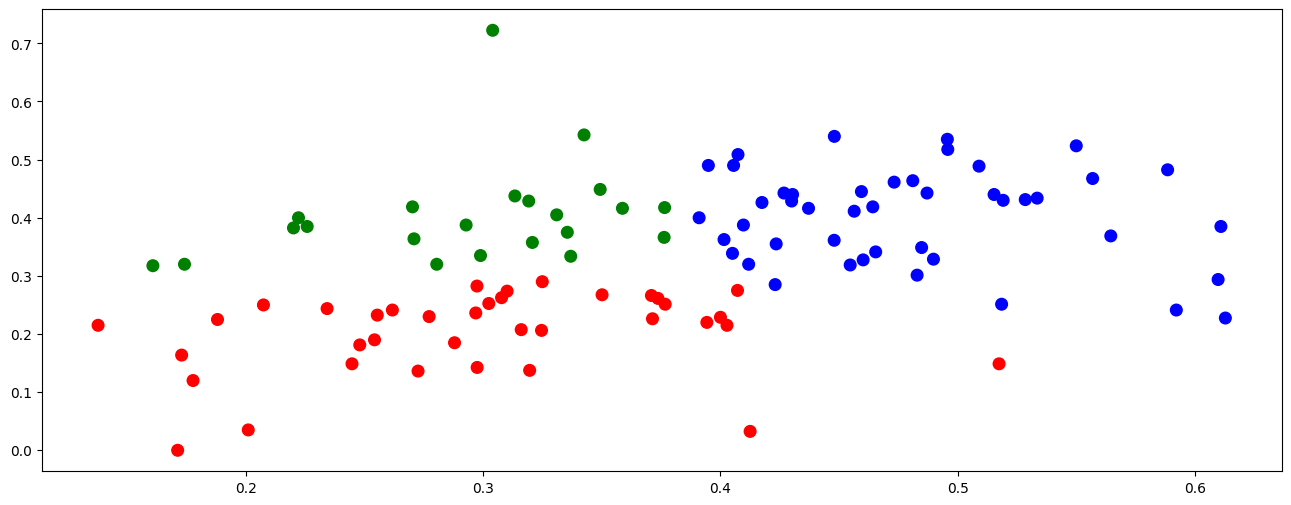

In [ ]:
# Seleccionamos un número de clusters K. Cambiar K=1 por el número que consideres.
# Recomendación: hay que mirar en la inercia y el score, quizás podemos apostar por un poquito de menos score.
K = 3
y_pred = Exec_KMeans(K, A)

Centros de los clusters:  [[0.25714212 0.178125  ]
 [0.47145276 0.46604167]
 [0.44804517 0.28317308]
 [0.29828882 0.36927083]]


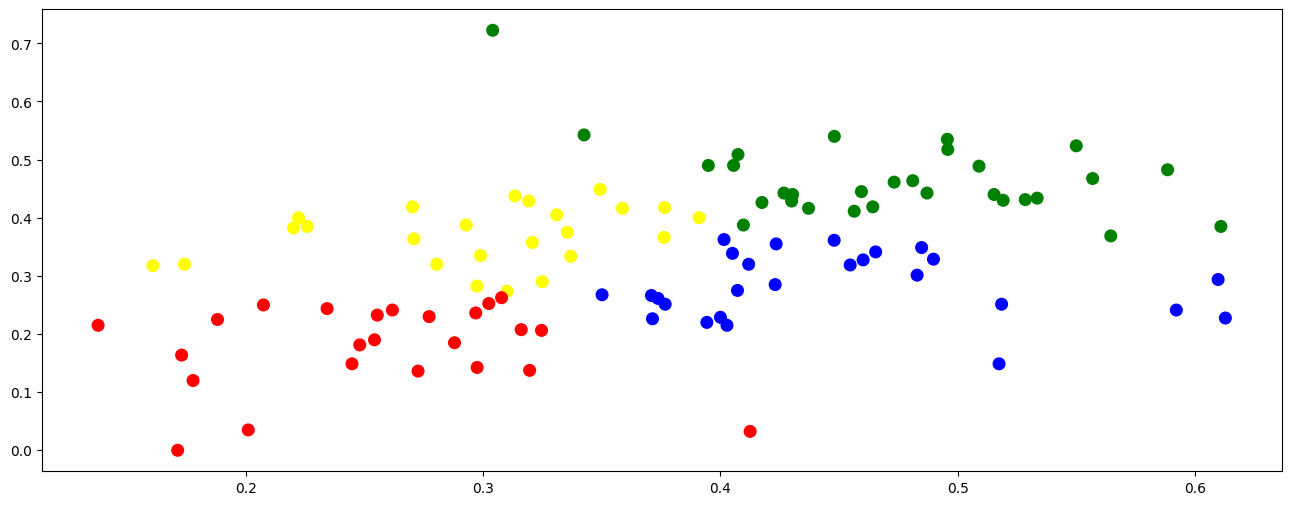

In [ ]:
K = 4
y_pred = Exec_KMeans(K, A)

Centros de los clusters:  [[0.25714212 0.178125  ]
 [0.47145276 0.46604167]
 [0.44804517 0.28317308]
 [0.29828882 0.36927083]]


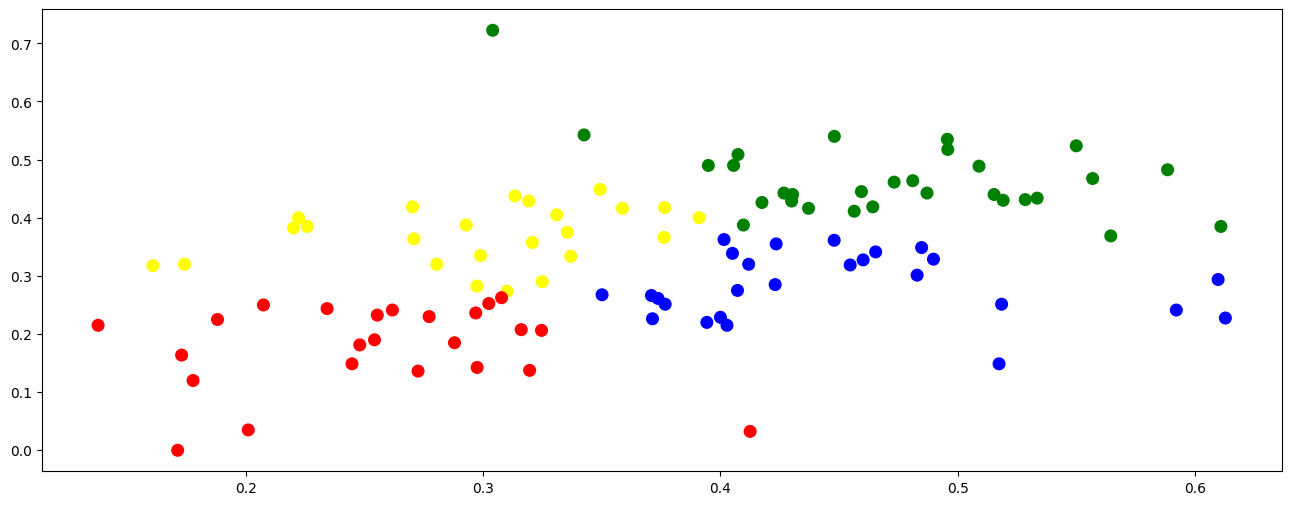

,Player,Age,Club,Country,Position,Goals_per_game,Shots_per_game,Touches,Accurate_per_game,Porcentaje_accurate,Interceptions_per_game,Tackles_per_game,%Total_duels_won,%Aerial_duels_won,DatosA,DatosB,Cluster
0,Daichi Kamada,26,Eint Frankfurt,Alemania,MF,0.7,1.2,47.3,29.5,81,1.0,2.5,61,57,0.588455,0.48250,1
1,Kota Kudo,19,Fujieda MYFC,Japon,DF,0.0,1.0,75.0,59.0,89,1.0,1.0,75,67,0.556862,0.46750,1
2,Atsuki Ito,24,Urawa Reds,Japon,MF,0.1,1.2,60.1,38.1,84,1.2,2.9,61,65,0.495654,0.53500,1
3,Nagi Matsumoto,21,Ventforet Kofu,Japon,MF,0.0,0.0,49.0,21.0,72,3.0,5.0,64,50,0.304086,0.72250,1
4,Shuto Machino,23,Shonan Bellmare,Japon,FW,0.5,3.3,44.0,19.8,71,0.2,0.4,38,40,0.612784,0.22750,2
5,Shogo Taniguchi,31,Kawa Frontale,Japon,DF,0.0,0.0,70.2,57.2,91,0.7,0.8,64,42,0.484817,0.34875,2
6,Reo Hatate,25,Celtic,Escocia,MF,0.2,1.8,62.3,40.6,82,0.3,1.2,57,59,0.564513,0.36875,1
7,Shunki Higashi,22,Sanfrecce Hiroshima,Japon,MF,0.1,1.2,61.6,28.9,74,0.7,0.8,51,43,0.454720,0.31875,2
8,Haruya Fujii,22,Nagoya Grampus,Japon,DF,0.1,0.8,60.7,34.8,76,1.4,1.9,66,77,0.448040,0.54000,1
9,Ryotaro Tsunoda,23,Yokohama Marinos,Japon,DF,0.0,0.3,75.5,53.8,86,2.6,1.3,58,58,0.495831,0.51750,1


In [ ]:
# Ejecutamos KMeans con el número de clusters (K) que hayas elegido y guardalo en una variable 'Cluster'
# en el dataset original (dt, si es tu caso)
Kseleccionado = 4
J1['Cluster'] = Exec_KMeans(Kseleccionado, A)
#plt.savefig('B.png', transparent=True)
J1.head(30)

In [ ]:
J1.to_excel('/content/drive/MyDrive/Proyecto Final Master/TOTALJAP.xlsx',sheet_name='TOTALJAP')

In [ ]:
MediocampoJap.sort_values(['DatosA']).head(3)

,Player,Age,Club,Country,Position,Goals_per_game,Shots_per_game,Touches,Accurate_per_game,Porcentaje_accurate,Interceptions_per_game,Tackles_per_game,%Total_duels_won,%Aerial_duels_won,DatosA,DatosB
101,Riku Ochiai,24,Kashiwa Reysol,Japon,MF,0.0,0.0,2.0,0.0,0,0.0,0.0,0,0,0.000000,0.00000
103,Yuta Matsumura,22,Kashima Antlers,Japon,MF,0.0,0.3,12.3,3.0,62,0.1,0.6,31,20,0.173037,0.16375
85,Takatora Einaga,20,Mito Hollyhock,Japon,MF,0.0,0.0,18.0,5.5,69,1.0,1.0,45,0,0.188147,0.22500


In [ ]:
MediocampoJap.drop(MediocampoJap[(MediocampoJap['DatosA'] == 0)].index, inplace=True)
MediocampoJap.sort_values(['DatosA']).head()

,Player,Age,Club,Country,Position,Goals_per_game,Shots_per_game,Touches,Accurate_per_game,Porcentaje_accurate,Interceptions_per_game,Tackles_per_game,%Total_duels_won,%Aerial_duels_won,DatosA,DatosB
103,Yuta Matsumura,22,Kashima Antlers,Japon,MF,0.0,0.3,12.3,3.0,62,0.1,0.6,31,20,0.173037,0.16375
85,Takatora Einaga,20,Mito Hollyhock,Japon,MF,0.0,0.0,18.0,5.5,69,1.0,1.0,45,0,0.188147,0.22500
80,Tsubasa Terayama,23,FC Tokyo,Japon,MF,0.0,0.0,20.3,10.3,79,0.0,0.7,65,75,0.225934,0.38500
99,Rihito Yamamoto,21,Gamba Osaka,Japon,MF,0.0,0.3,18.7,10.4,81,0.5,0.1,27,18,0.244816,0.14875
83,Hidetoshi Takeda,21,Mito Hollyhock,Japon,MF,0.0,0.4,20.0,11.8,80,0.4,0.5,40,33,0.255466,0.23250


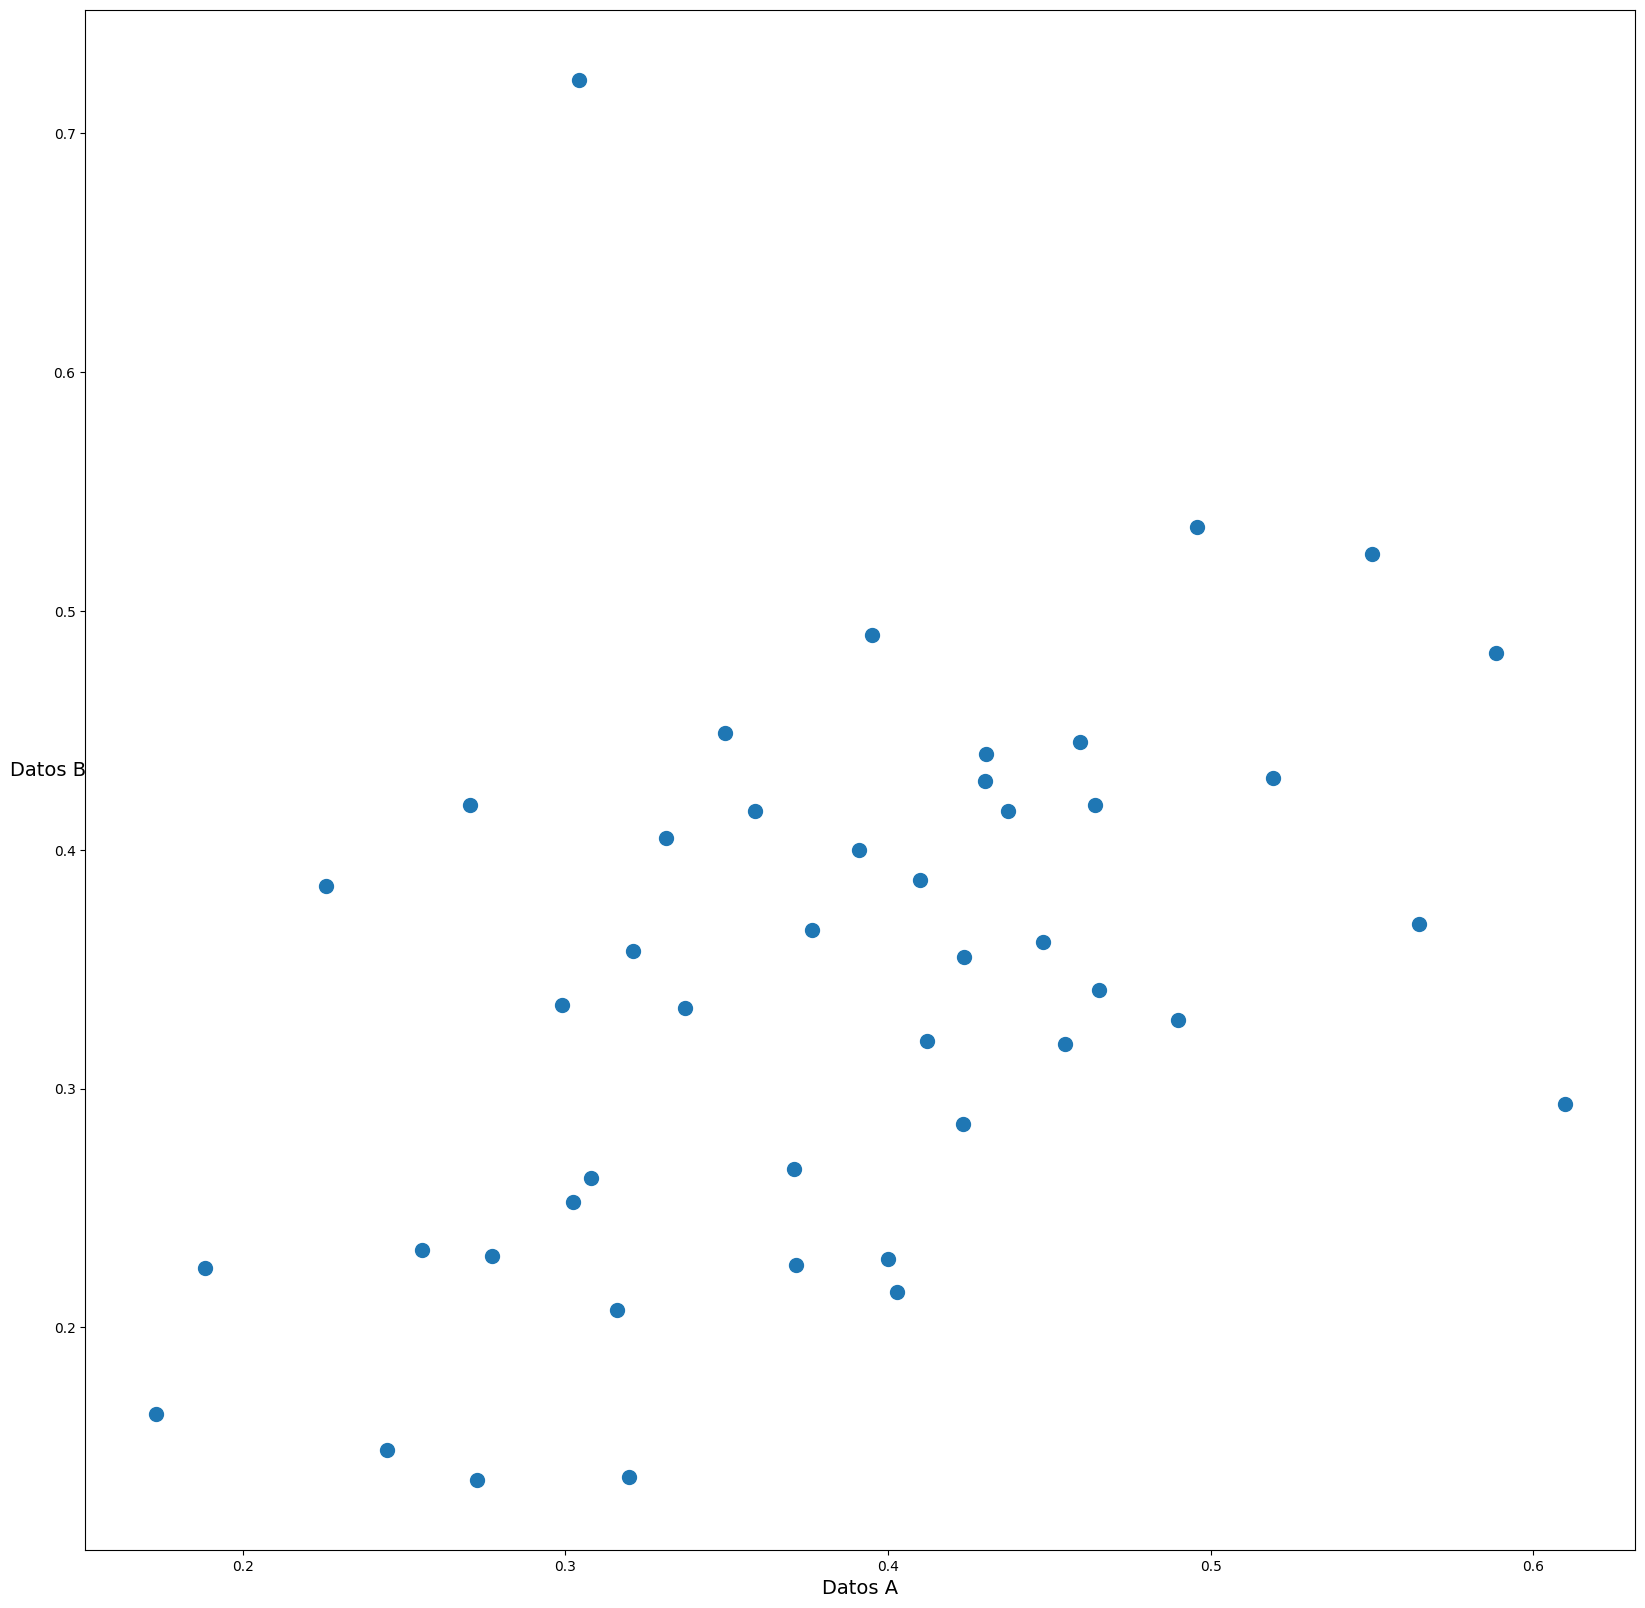

In [ ]:
# Visualizamos los datos
C = MediocampoJap[['DatosA', 'DatosB']].values
plt.figure(figsize=(20, 20))
plt.scatter(C[:, 0], C[:, 1], c=None, s=100)
plt.xlabel("Datos A", fontsize=14)
plt.ylabel("Datos B", fontsize=14, rotation=0)
plt.show()

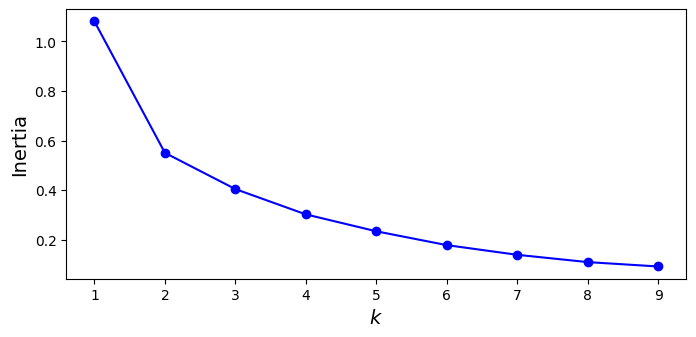

In [ ]:
# Visualizamos la inercia
kmeans_per_k = [KMeans(n_clusters=k, random_state=42).fit(C)
                for k in range(1, 10)]
inertias = [model.inertia_ for model in kmeans_per_k]

plt.figure(figsize=(8, 3.5))
plt.plot(range(1, 10), inertias, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Inertia", fontsize=14)

plt.show()


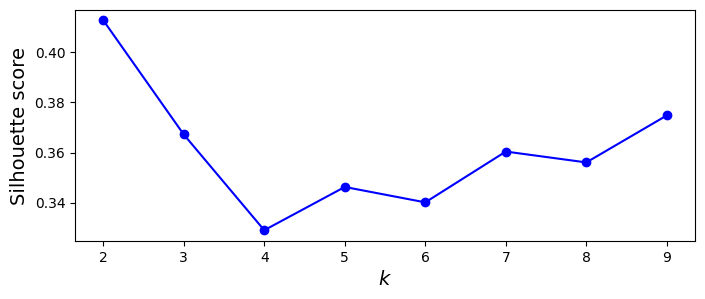

In [ ]:
# Visualizamos el sillhoute score
silhouette_scores = [silhouette_score(C, model.labels_) for model in kmeans_per_k[1:]]

plt.figure(figsize=(8, 3))
plt.plot(range(2, 10), silhouette_scores, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Silhouette score", fontsize=14)

plt.show()

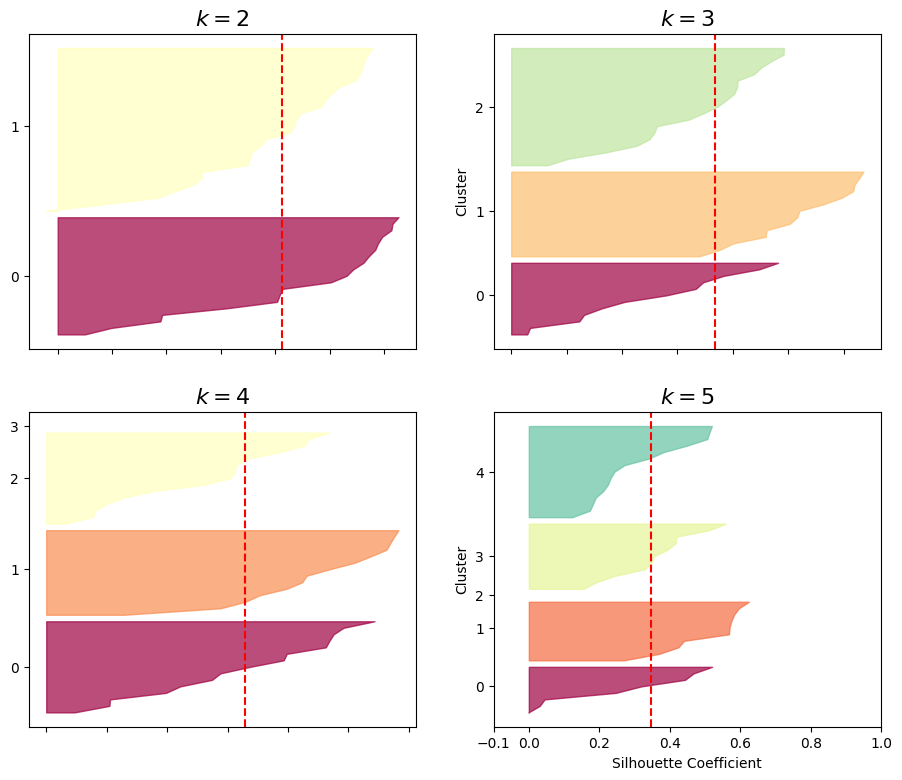

In [ ]:
# Pruebo el metodo de visualizacion de clusteres para sacarme la duda entre K = 2, K = 3, K = 5
plt.figure(figsize=(11, 9))

for k in (2, 3, 4, 5):
    plt.subplot(2, 2, k - 1)

    y_pred = kmeans_per_k[k - 1].labels_
    silhouette_coefficients = silhouette_samples(C, y_pred)

    padding = len(B) // 30
    pos = padding
    ticks = []
    for i in range(k):
        coeffs = silhouette_coefficients[y_pred == i]
        coeffs.sort()

        color = plt.cm.Spectral(i / k)
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))
    if k in (3, 5):
        plt.ylabel("Cluster")

    if k in (5, 6):
        plt.gca().set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
        plt.xlabel("Silhouette Coefficient")
    else:
        plt.tick_params(labelbottom=False)

    plt.axvline(x=silhouette_scores[k - 2], color="red", linestyle="--")
    plt.title("$k={}$".format(k), fontsize=16)

plt.show()

In [ ]:
# Dejar así
def Exec_KMeans(k, X):

    kmeans = KMeans(n_clusters=k, random_state=42)
    y_pred = kmeans.fit_predict(X)

    print("Centros de los clusters: ", kmeans.cluster_centers_)

    plt.figure(figsize=(16, 6))
    cl = ['red', 'green', 'blue', 'yellow', 'black']
    assign = []
    for row in y_pred:
        assign.append(cl[row])

    plt.scatter(X[:,0], X[:,1], c=assign, s=70 )

    plt.show()

    return y_pred

Centros de los clusters:  [[0.32988578 0.42322917]
 [0.30019465 0.20946429]
 [0.47763507 0.39368421]]


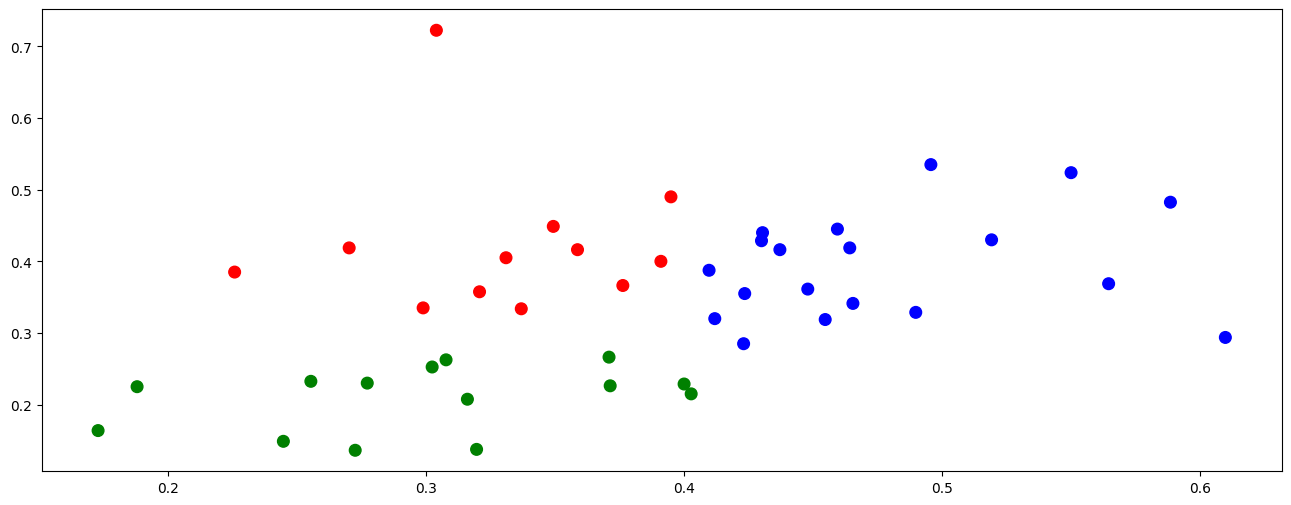

In [ ]:
K = 3
y_pred = Exec_KMeans(K, C)

Centros de los clusters:  [[0.32988578 0.42322917]
 [0.30019465 0.20946429]
 [0.47763507 0.39368421]]


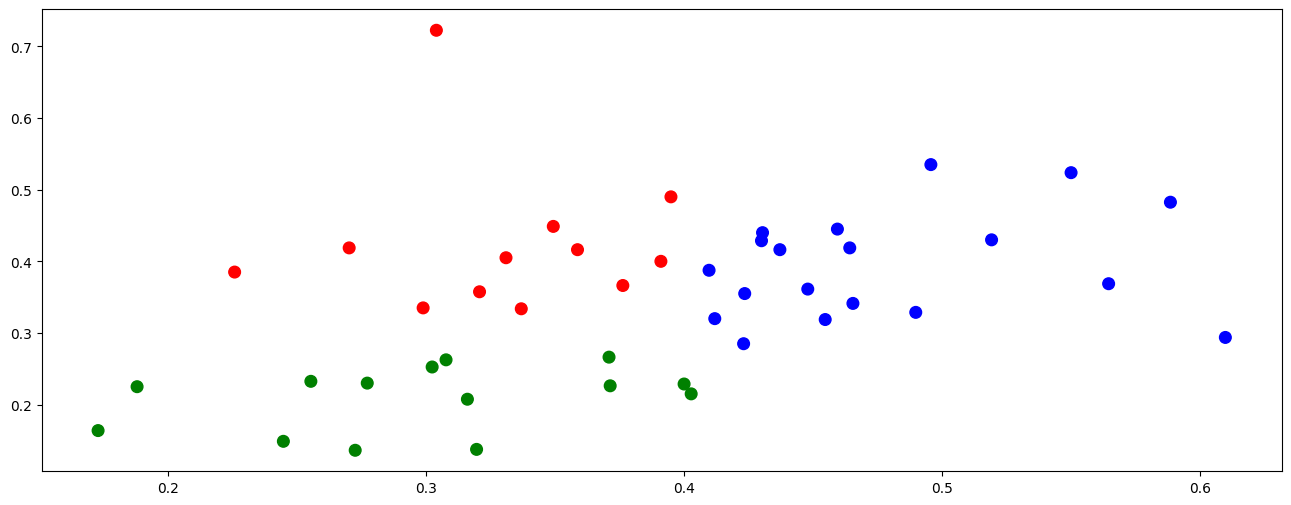

,Player,Age,Club,Country,Position,Goals_per_game,Shots_per_game,Touches,Accurate_per_game,Porcentaje_accurate,Interceptions_per_game,Tackles_per_game,%Total_duels_won,%Aerial_duels_won,DatosA,DatosB,Cluster
0,Daichi Kamada,26,Eint Frankfurt,Alemania,MF,0.7,1.2,47.3,29.5,81,1.0,2.5,61,57,0.588455,0.48250,2
2,Atsuki Ito,24,Urawa Reds,Japon,MF,0.1,1.2,60.1,38.1,84,1.2,2.9,61,65,0.495654,0.53500,2
3,Nagi Matsumoto,21,Ventforet Kofu,Japon,MF,0.0,0.0,49.0,21.0,72,3.0,5.0,64,50,0.304086,0.72250,0
6,Reo Hatate,25,Celtic,Escocia,MF,0.2,1.8,62.3,40.6,82,0.3,1.2,57,59,0.564513,0.36875,2
7,Shunki Higashi,22,Sanfrecce Hiroshima,Japon,MF,0.1,1.2,61.6,28.9,74,0.7,0.8,51,43,0.454720,0.31875,2
10,Keito Nakamura,22,Lask,Austria,MF,0.5,2.9,49.4,21.0,74,0.7,1.0,45,35,0.609734,0.29375,2
16,Hayao Kawabe,27,Grasshopper Club Zürich,Suiza,MF,0.3,1.1,38.7,19.0,75,0.8,1.5,50,42,0.423536,0.35500,2
17,Takumu Kawamura,23,Sanfrecce hiroshima,Japon,MF,0.1,2.6,36.3,16.1,79,1.4,2.8,49,38,0.459448,0.44500,2
20,Hidemasa Morita,28,Sporting CP,Portugal,MF,0.2,1.0,46.4,30.6,87,0.9,1.7,50,61,0.464231,0.41875,2
21,Wataru Endo,30,Stuttgart,Alemania,MF,0.2,1.4,60.9,35.3,80,0.8,2.1,52,58,0.519169,0.43000,2


In [ ]:
# Ejecutamos KMeans con el número de clusters (K) que hayas elegido y guardalo en una variable 'Cluster'
# en el dataset original (dt, si es tu caso)
Kseleccionado = 3
MediocampoJap['Cluster'] = Exec_KMeans(Kseleccionado, C)
#plt.savefig('B.png', transparent=True)
MediocampoJap.head(10)

In [ ]:
MediocampoJap.to_excel("/content/drive/MyDrive/Proyecto Final Master/MEDjap.xlsx",sheet_name='MEDjap')

In [ ]:
DefensaJap.sort_values(['DatosA']).head(3)

,Player,Age,Club,Country,Position,Goals_per_game,Shots_per_game,Touches,Accurate_per_game,Porcentaje_accurate,Interceptions_per_game,Tackles_per_game,%Total_duels_won,%Aerial_duels_won,DatosA,DatosB
106,Hayate Matsuda,19,Mito Hollyhock,Japon,DF,0.0,0.3,15.3,2.7,53,0.0,0.3,46,75,0.160927,0.3175
75,Ayumu Ohata,22,Urawa Reds,Japon,DF,0.0,0.3,5.5,2.8,69,0.0,0.0,0,0,0.171365,0.0000
104,Takashi Uchino,22,Fortuna Düsseldorf,Alemania,DF,0.0,0.0,10.3,6.3,83,0.0,0.0,14,0,0.201108,0.0350


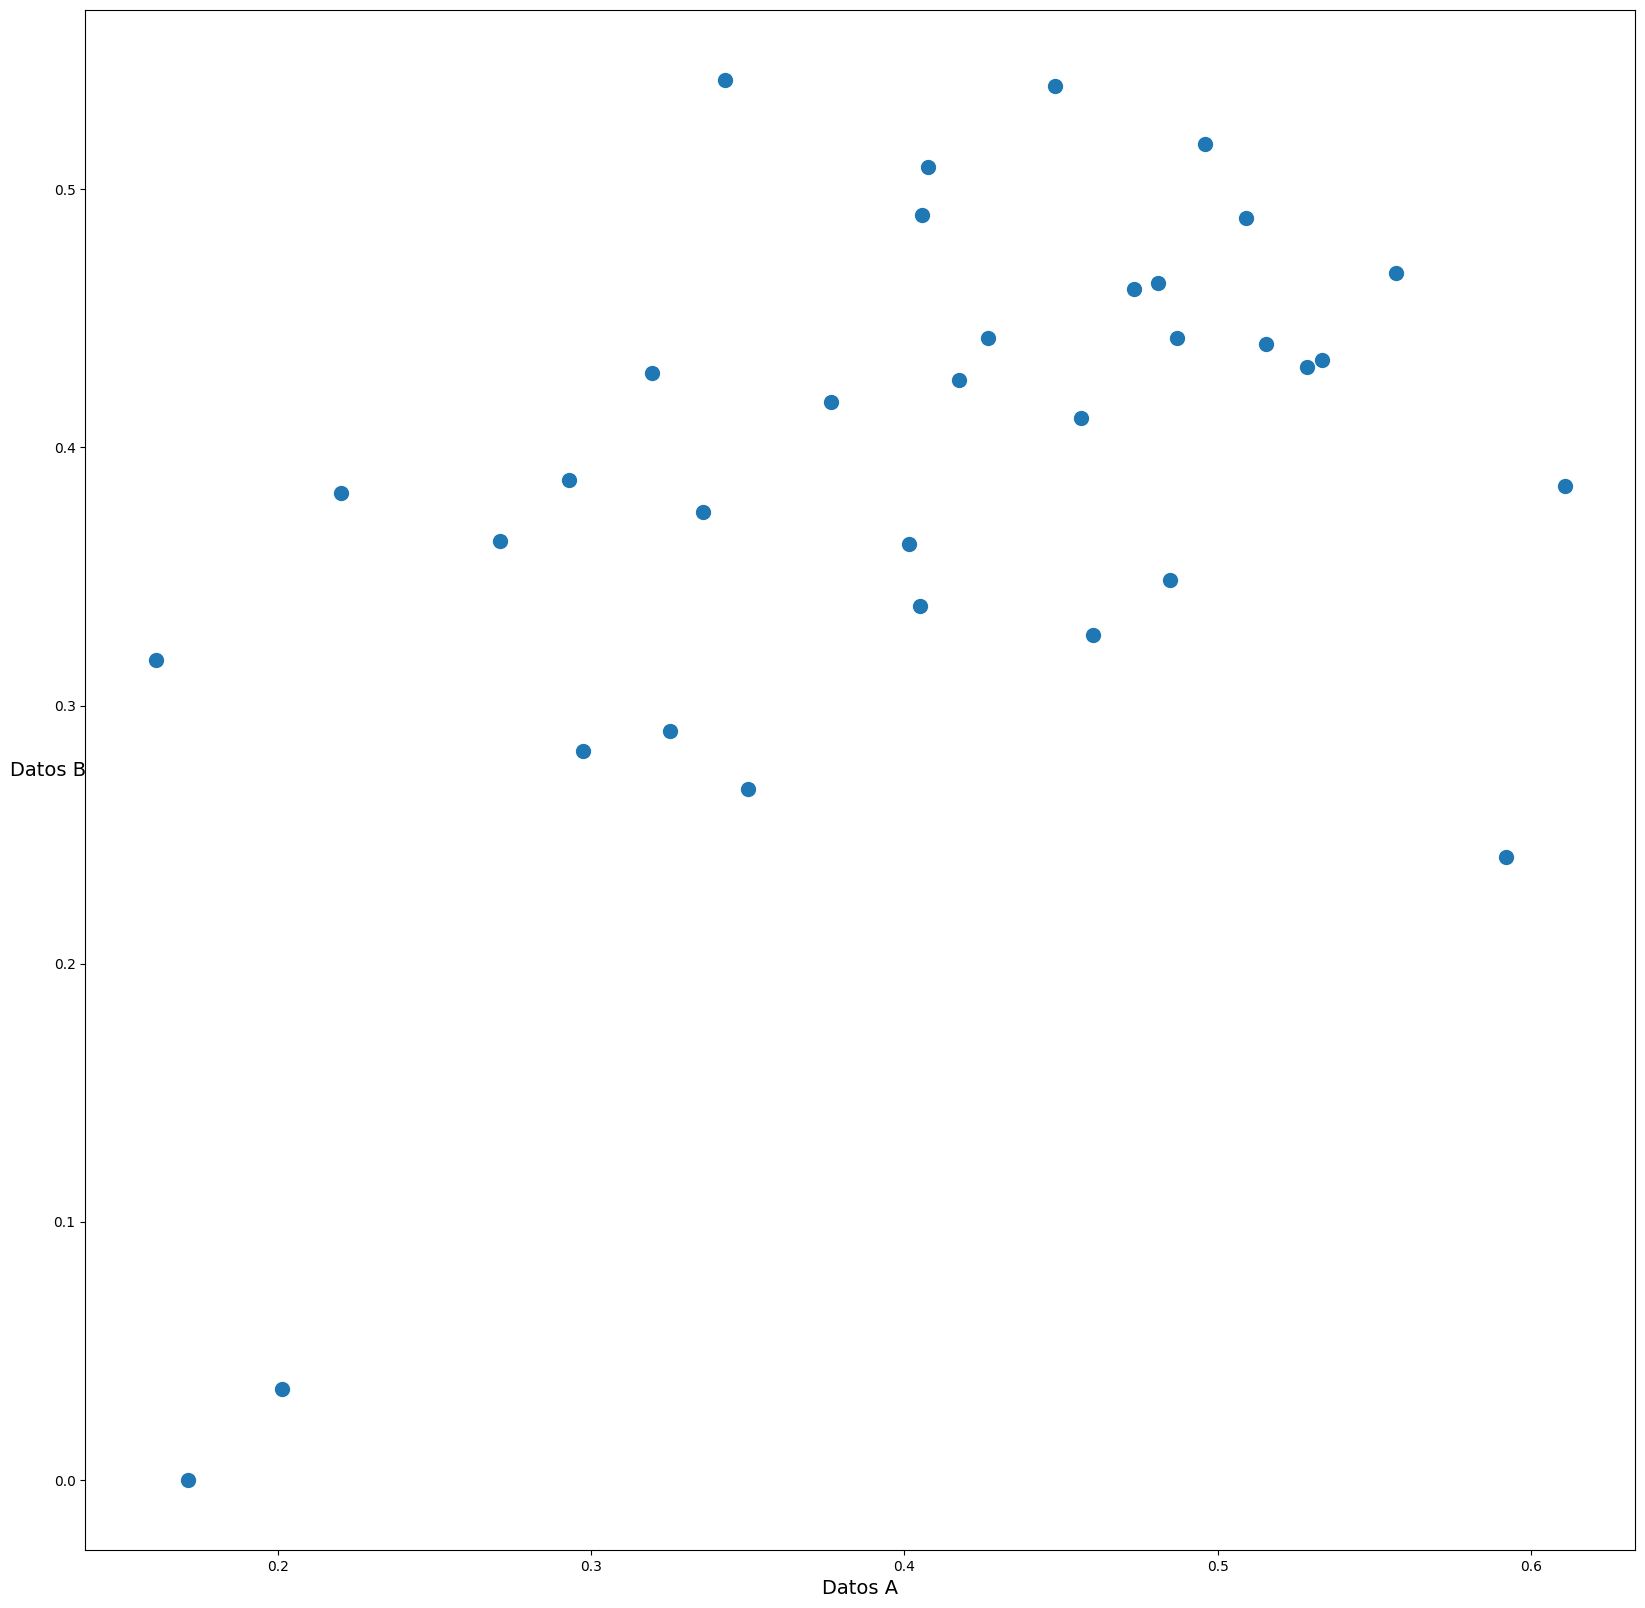

In [ ]:
# Visualizamos los datos
D = DefensaJap[['DatosA', 'DatosB']].values
plt.figure(figsize=(20, 20))
plt.scatter(D[:, 0], D[:, 1], c=None, s=100)
plt.xlabel("Datos A", fontsize=14)
plt.ylabel("Datos B", fontsize=14, rotation=0)
plt.show()

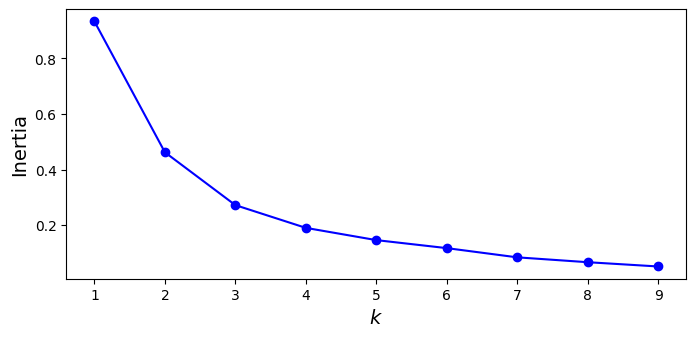

In [ ]:
# Visualizamos la inercia
kmeans_per_k = [KMeans(n_clusters=k, random_state=42).fit(D)
                for k in range(1, 10)]
inertias = [model.inertia_ for model in kmeans_per_k]

plt.figure(figsize=(8, 3.5))
plt.plot(range(1, 10), inertias, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Inertia", fontsize=14)

plt.show()

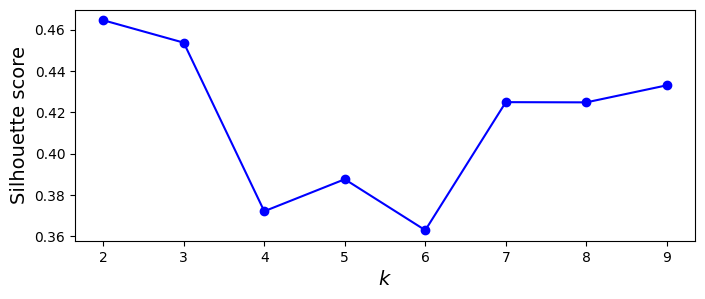

In [ ]:
# Visualizamos el sillhoute score
silhouette_scores = [silhouette_score(D, model.labels_) for model in kmeans_per_k[1:]]

plt.figure(figsize=(8, 3))
plt.plot(range(2, 10), silhouette_scores, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Silhouette score", fontsize=14)

plt.show()

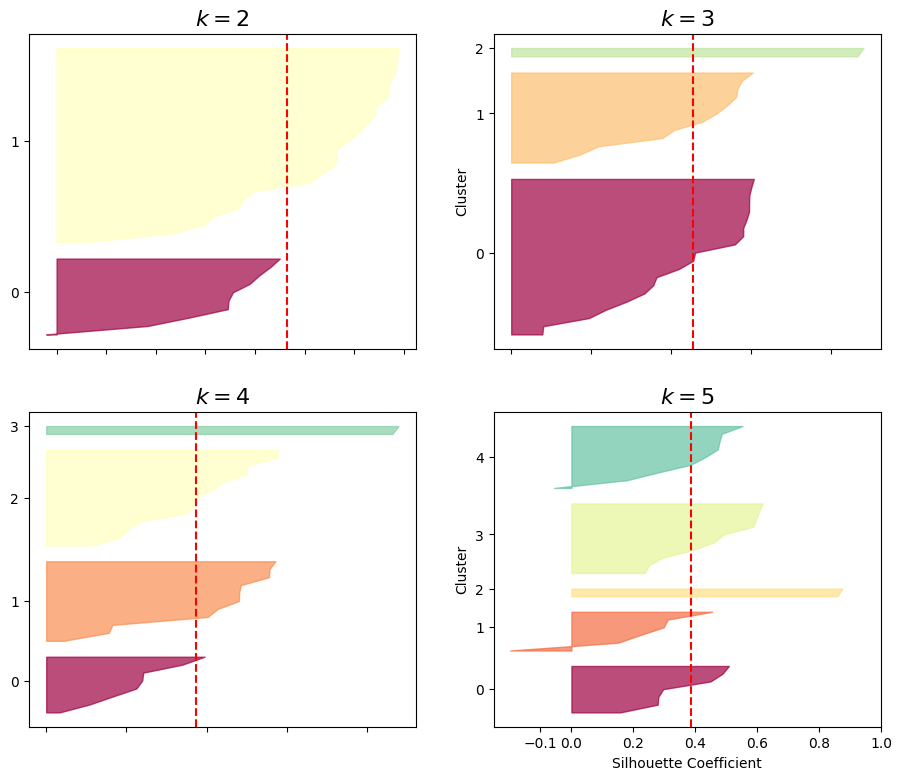

In [ ]:
# Pruebo el metodo de visualizacion de clusteres para sacarme la duda entre K = 2, K = 3, K = 5
plt.figure(figsize=(11, 9))

for k in (2, 3, 4, 5):
    plt.subplot(2, 2, k - 1)

    y_pred = kmeans_per_k[k - 1].labels_
    silhouette_coefficients = silhouette_samples(D, y_pred)

    padding = len(D) // 30
    pos = padding
    ticks = []
    for i in range(k):
        coeffs = silhouette_coefficients[y_pred == i]
        coeffs.sort()

        color = plt.cm.Spectral(i / k)
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))
    if k in (3, 5):
        plt.ylabel("Cluster")

    if k in (5, 6):
        plt.gca().set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
        plt.xlabel("Silhouette Coefficient")
    else:
        plt.tick_params(labelbottom=False)

    plt.axvline(x=silhouette_scores[k - 2], color="red", linestyle="--")
    plt.title("$k={}$".format(k), fontsize=16)

plt.show()

In [ ]:
# Dejar así
def Exec_KMeans(k, X):

    kmeans = KMeans(n_clusters=k, random_state=42)
    y_pred = kmeans.fit_predict(X)

    print("Centros de los clusters: ", kmeans.cluster_centers_)

    plt.figure(figsize=(16, 6))
    cl = ['red', 'green', 'blue', 'yellow', 'black']
    assign = []
    for row in y_pred:
        assign.append(cl[row])

    plt.scatter(X[:,0], X[:,1], c=assign, s=70 )

    plt.show()

    return y_pred

Centros de los clusters:  [[0.48164191 0.4405    ]
 [0.31296402 0.35114583]
 [0.1862365  0.0175    ]]


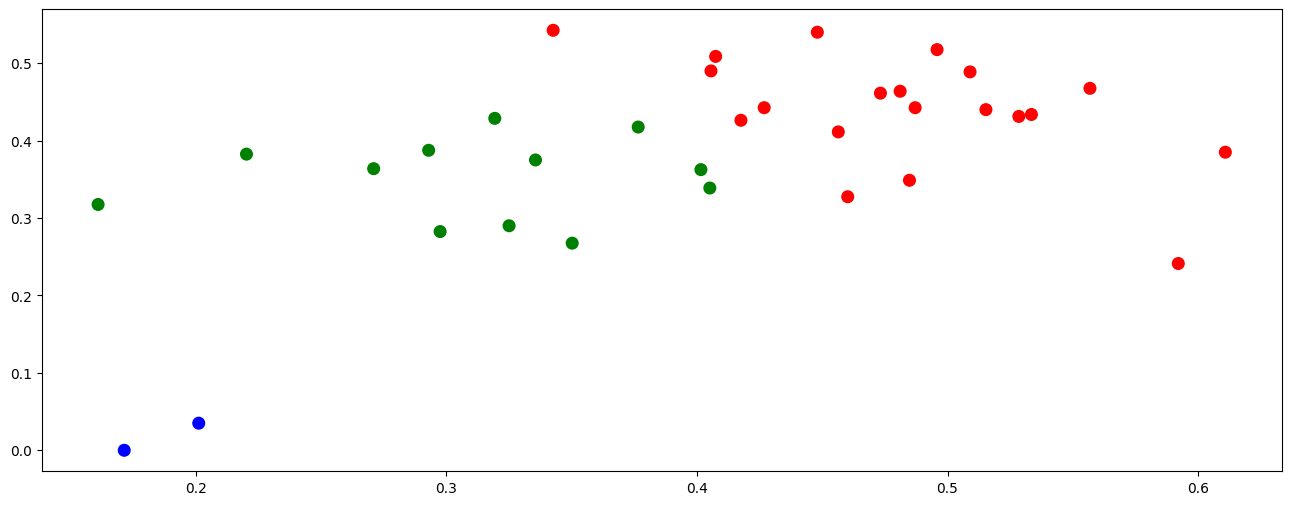

In [ ]:
K = 3
y_pred = Exec_KMeans(K, D)

Centros de los clusters:  [[0.48164191 0.4405    ]
 [0.31296402 0.35114583]
 [0.1862365  0.0175    ]]


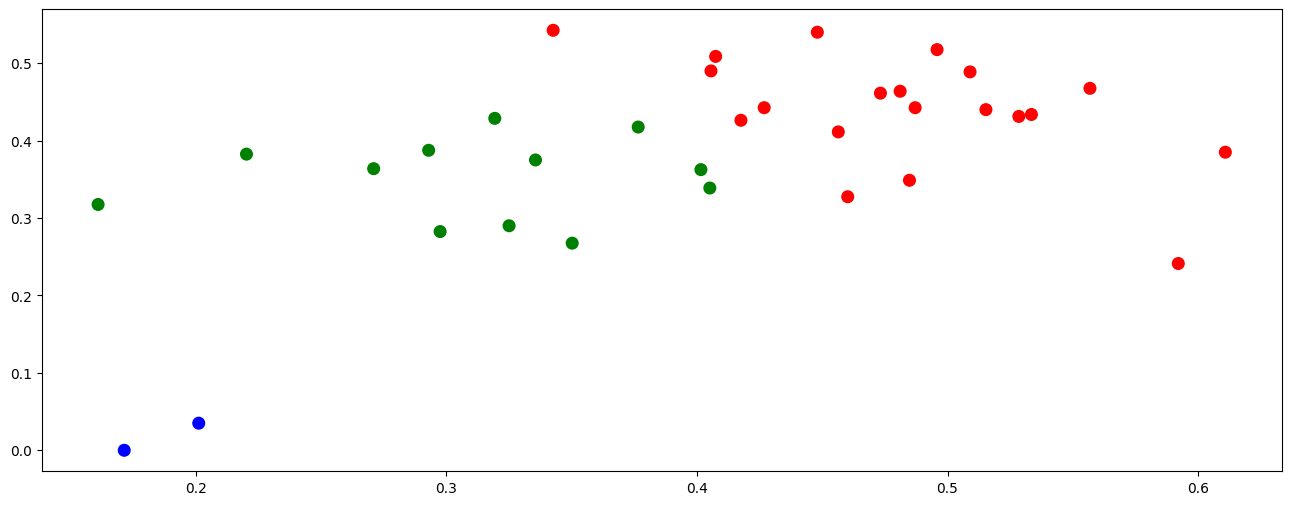

,Player,Age,Club,Country,Position,Goals_per_game,Shots_per_game,Touches,Accurate_per_game,Porcentaje_accurate,Interceptions_per_game,Tackles_per_game,%Total_duels_won,%Aerial_duels_won,DatosA,DatosB,Cluster
1,Kota Kudo,19,Fujieda MYFC,Japon,DF,0.0,1.0,75.0,59.0,89,1.0,1.0,75,67,0.556862,0.46750,0
5,Shogo Taniguchi,31,Kawa Frontale,Japon,DF,0.0,0.0,70.2,57.2,91,0.7,0.8,64,42,0.484817,0.34875,0
8,Haruya Fujii,22,Nagoya Grampus,Japon,DF,0.1,0.8,60.7,34.8,76,1.4,1.9,66,77,0.448040,0.54000,0
9,Ryotaro Tsunoda,23,Yokohama Marinos,Japon,DF,0.0,0.3,75.5,53.8,86,2.6,1.3,58,58,0.495831,0.51750,0
12,Anrie Chase,19,VfB Stuttgart II,Alemania,DF,0.0,0.7,73.3,50.7,87,1.3,1.7,62,67,0.508995,0.48875,0
13,Yukinari Sugawara,22,AZ Alkmaar,Países Bajos,DF,0.1,0.9,57.9,33.4,84,0.6,1.6,53,31,0.460171,0.32750,0
18,Ko Itakura,26,M'Gladbach,Alemania,DF,0.0,0.5,76.2,59.1,91,1.1,1.2,62,60,0.533496,0.43375,0
19,Sota Miura,22,Ventforet Kofu,Japon,DF,0.0,1.0,65.0,12.0,55,4.0,3.0,57,0,0.342580,0.54250,0
23,Hiroki Ito,24,Stuttgart,Alemania,DF,0.0,0.7,80.9,54.7,83,1.3,1.3,58,56,0.528475,0.43125,0
24,Kota Takai,18,Kawasaki Frontale,Japon,DF,0.0,0.2,71.6,53.8,89,1.0,1.6,59,61,0.487085,0.44250,0


In [ ]:
# Ejecutamos KMeans con el número de clusters (K) que hayas elegido y guardalo en una variable 'Cluster'
# en el dataset original (dt, si es tu caso)
Kseleccionado = 3
DefensaJap['Cluster'] = Exec_KMeans(Kseleccionado, D)
#plt.savefig('B.png', transparent=True)
DefensaJap.head(10)

In [ ]:
DefensaJap.to_excel('/content/drive/MyDrive/Proyecto Final Master/DEFjap.xlsx', sheet_name='DEFjap')

**REDUCCION DE DIMENSIONALIDAD**

In [3]:
# Cargamos el dataset (en la carpeta data con nombre PCA)
J2 = pd.read_excel('/content/drive/MyDrive/Proyecto Final Master/ModeloAnalitico2.xlsx')

In [4]:
# Visualizar las 5 primeras muestras del dataset
J2.head(1)

,Indice,AA Player,Age,Club,Country,Position,Attacking,Creativity,Defending,Tactical,Technical,Rating,Goals_per_game,Shots_per_game,Touches,Accurate_per_game,Porcentaje_accurate,Interceptions_per_game,Tackles_per_game,%Total_duels_won,%Aerial_duels_won
0,1,Daichi Kamada,26,Eint Frankfurt,Alemania,MF,66.0,63.0,38.0,49.0,66.0,7.43,0.7,1.2,47.3,29.5,81,1.0,2.5,61,57


In [5]:
J2.columns

Index(['Indice', 'AA Player', 'Age', 'Club', 'Country', 'Position',
       'Attacking', 'Creativity', 'Defending', 'Tactical', 'Technical',
       'Rating', 'Goals_per_game', 'Shots_per_game', 'Touches',
       'Accurate_per_game', 'Porcentaje_accurate', 'Interceptions_per_game',
       'Tackles_per_game', '%Total_duels_won', '%Aerial_duels_won'],
      dtype='object')

In [6]:
J2 = J2[['AA Player', 'Age',
       'Rating', 'Goals_per_game', 'Shots_per_game', 'Touches',
       'Accurate_per_game', 'Porcentaje_accurate', 'Interceptions_per_game',
       'Tackles_per_game', '%Total_duels_won', '%Aerial_duels_won']]

In [ ]:
#Faltan los datos de Creativity hasta Technical, esto afectaria la matriz de correlacion por eso: borramos esas columnas
#J2 = J2[['AA Player', 'Age','Attacking', 'Creativity', 'Defending', 'Tactical', 'Technical','Rating',
#       'Goals_per_game', 'Shots_per_game', 'Touches',
#       'Accurate_per_game', 'Porcentaje_accurate', 'Interceptions_per_game',
#      'Tackles_per_game', '%Total_duels_won', '%Aerial_duels_won']]
#J2 = J2.fillna(0)

In [7]:
J2.head(3)

,AA Player,Age,Rating,Goals_per_game,Shots_per_game,Touches,Accurate_per_game,Porcentaje_accurate,Interceptions_per_game,Tackles_per_game,%Total_duels_won,%Aerial_duels_won
0,Daichi Kamada,26,7.43,0.7,1.2,47.3,29.5,81,1.0,2.5,61,57
1,Kota Kudo,19,7.40,0.0,1.0,75.0,59.0,89,1.0,1.0,75,67
2,Atsuki Ito,24,7.30,0.1,1.2,60.1,38.1,84,1.2,2.9,61,65


In [8]:
# Visualizar los tipos de dato de cada variable
J2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107 entries, 0 to 106
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   AA Player               107 non-null    object 
 1   Age                     107 non-null    int64  
 2   Rating                  107 non-null    float64
 3   Goals_per_game          107 non-null    float64
 4   Shots_per_game          107 non-null    float64
 5   Touches                 107 non-null    float64
 6   Accurate_per_game       107 non-null    float64
 7   Porcentaje_accurate     107 non-null    int64  
 8   Interceptions_per_game  107 non-null    float64
 9   Tackles_per_game        107 non-null    float64
 10  %Total_duels_won        107 non-null    int64  
 11  %Aerial_duels_won       107 non-null    int64  
dtypes: float64(7), int64(4), object(1)
memory usage: 10.2+ KB


In [9]:
# Pasamos las métricas a una matriz X y los nombres de los jugadores a una matriz y
matrX, matrY = J2.iloc[:, 1:len(J2.columns)].values, J2.iloc[:, 0].values

In [10]:
# Escalamos la matriz X
X_std_dim = StandardScaler().fit_transform(matrX)

In [11]:
# Aplicamos PCA para obtener una matriz x pero con las dimensiones (X_pca)
pca = PCA(n_components = len(J2.columns)-1)
pca.fit(X_std_dim)
X_pca = pca.transform(X_std_dim)

Shape x_PCA:  (107, 11)
Explained Variance: 0 components: 0
Explained Variance: 2 components: 0.5874116424424826
Explained Variance: 4 components: 0.78761941594999
Explained Variance: 6 components: 0.9054671229131493
Explained Variance: 8 components: 0.962983180683141
Explained Variance: 10 components: 0.9970583772843278


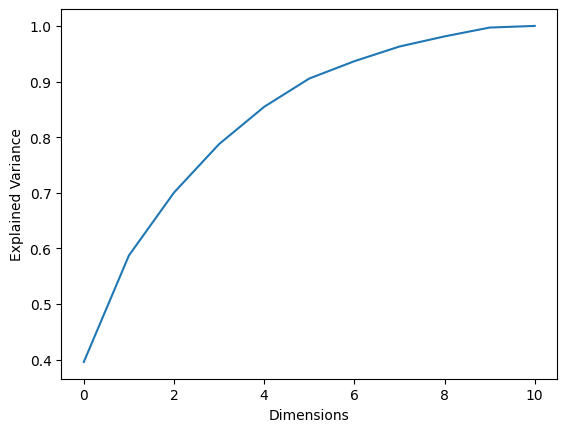

In [12]:
# Visualizamos las dimensiones para determinar qué número nos interesa más
print("Shape x_PCA: ", X_pca.shape)
expl = pca.explained_variance_ratio_

for x in range(0, len(J2.columns), 2):
    print("Explained Variance: " + str(x) + " components:", sum(expl[0:x]))

plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Dimensions')
plt.ylabel('Explained Variance')
plt.show()

In [13]:
# Seleccionamos el número de componentes y mostramos (head) el dataframe con las dimensiones
N_COMP = 8
columns = []

for col in range(1, N_COMP+1, 1):
    columns.append("PCA" + str(col))

J2_pca_resultado = pd.DataFrame(data=X_pca[:,0:N_COMP], columns=columns, index = matrY)

J2_pca_resultado.head()

,PCA1,PCA2,PCA3,PCA4,PCA5,PCA6,PCA7,PCA8
Daichi Kamada,-2.635101,3.670246,0.199337,-0.325230,-0.838475,-0.395523,1.061389,2.058147
Kota Kudo,-3.517691,-0.246874,-0.880195,-1.179165,1.243823,-1.013017,1.297250,-0.944768
Atsuki Ito,-3.320651,0.819798,0.605234,-0.367636,-0.699749,-0.275640,0.085329,-0.266951
Nagi Matsumoto,-4.035128,-0.920275,3.780486,-1.429080,-2.858314,0.039949,0.143267,0.912078
Shuto Machino,0.068924,4.761830,-0.329423,-0.582722,1.047518,-0.978211,0.014860,-0.831843


In [14]:
# Obtenemos la matriz de correlación (Pearson)
corr_matrix_pca = J2_pca_resultado.T.corr(method='pearson')

In [15]:
# Mostramos las primeras 5 muestras (head)
corr_matrix_pca.head(5)

,Daichi Kamada,Kota Kudo,Atsuki Ito,Nagi Matsumoto,Shuto Machino,Shogo Taniguchi,Reo Hatate,Shunki Higashi,Haruya Fujii,Ryotaro Tsunoda,Keito Nakamura,Kyogo Furuhashi,Anrie Chase,Yukinari Sugawara,Ayase Ueda,Takefusa Kubo,Hayao Kawabe,Takumu Kawamura,Ko Itakura,Sota Miura,Hidemasa Morita,Wataru Endo,Yuki Soma,Hiroki Ito,Kota Takai,Kuryu Matsuki,Sota Kitano,Tomoki Iwata,Junya Ito,Miki Yamane,Ao Tanaka,Sota Kawasaki,Takehiro Ho,Hiroki Sakai,Yuito Suzuki,Hiroki Abe,Kaoru Mitoma,Yuta Nakayama,Daiki Hashioka,Koki Saito,Takuma Ominami,Maya Yoshida,Taichi Fukui,Yutaro Oda,Ryoya Morishita,Ritsu Doan,Kodai Sano,Riku Handa,Taisei Abe,Yuki Kobayashi,Gaku Shibasaki,Koki Machida,Daizen Maeda,Fuchi Honda,Joel Chima Fujita,Yoichi Naganuma,Daiki Sugioka,Niko Takahashi,Takumi Minamino,Mao Hosoya,Isa Sakamoto,Kosuke Matsumura,Taiga Hata,Ayumu Seko,Satoshi Tanaka,Takehiro Tomiyasu,Kashif Bangnagande,Ryuya Nishio,Takuma Asano,Yuto Nagatomo,Daiki Matsuoka,Shunsuke Mito,Fuki Yamada,Riku Yamane,Riyo Kawamoto,Ayumu Ohata,Jiro Nakamura,Kazunari Ichimi,Seiji Kimura,Takuma Nishimura,Tsubasa Terayama,Seiya Baba,Shio Fukuda,Hidetoshi Takeda,Jun Nishikawa,Takatora Einaga,Yuto Iwasaki,Shin Yamada,Shinya Nakano,Takumi Nakamura,Yuya Fukuda,Yudai Kimura,Taiyo Hiraoka,Naoki Kumata,Yugo Masukake,Toya Izumi,Itsuki Someno,Shun Ayukawa,Makoto Okazaki,Rihito Yamamoto,Hayato Tanaka,Riku Ochiai,Shota Fujio,Yuta Matsumura,Takashi Uchino,Yusei Yashiki,Hayate Matsuda
Daichi Kamada,1.000000,0.447987,0.783685,0.447916,0.560371,0.231348,0.674553,0.487488,0.753507,0.351373,0.656426,0.623687,0.407810,0.483835,0.558087,0.609595,0.896316,0.502413,0.276991,0.216319,0.749851,0.658682,0.225987,0.266177,0.211717,0.289229,-0.026412,0.300596,0.460462,0.362788,0.439661,0.487198,0.326302,0.486844,0.372817,-0.134293,0.611116,0.495674,0.216061,0.468227,0.115999,0.224128,-0.433627,-0.217271,0.314924,0.299752,-0.074976,0.445142,-0.331011,-0.163997,-0.026061,0.227408,0.170549,0.219111,0.205411,0.717462,0.352299,-0.135786,-0.128805,0.082054,-0.048776,-0.335699,-0.279538,-0.104793,-0.122875,-0.313418,-0.776025,-0.296066,-0.067170,-0.025016,-0.661675,0.080315,-0.499203,-0.210761,-0.376574,-0.823559,-0.714332,-0.616714,-0.102415,-0.212851,-0.279924,-0.422035,-0.629914,-0.787210,-0.733975,-0.629607,-0.753343,-0.583747,-0.579386,-0.520249,-0.579220,-0.672749,-0.237404,-0.306026,-0.744373,-0.404955,-0.509454,-0.294333,-0.640646,-0.829175,-0.459333,-0.647553,-0.641709,-0.795307,-0.825998,-0.651006,-0.613430
Kota Kudo,0.447987,1.000000,0.653868,0.220751,0.236277,0.728711,0.722458,0.882607,0.748036,0.745972,0.252726,-0.073391,0.900196,0.881381,-0.001441,0.175668,0.221321,0.035658,0.795631,0.136991,0.365487,0.379219,-0.164174,0.826049,0.834881,0.599726,-0.263644,0.774099,0.081868,0.526359,0.669525,0.241643,0.644280,0.134730,-0.042744,0.105288,0.137861,0.539024,0.245559,0.005699,0.647374,0.267570,-0.002360,-0.407335,0.125167,-0.233416,0.616174,0.302320,-0.021038,0.650012,-0.054266,0.536274,-0.498413,-0.209999,0.032257,-0.095930,0.496890,0.256128,-0.646533,-0.384003,-0.331631,-0.287120,0.127572,0.331764,-0.228541,-0.355094,-0.148481,0.106954,-0.465612,-0.162377,-0.504692,0.012068,-0.673429,0.295378,-0.712676,-0.724055,-0.412412,-0.709492,0.443185,-0.669744,-0.361169,-0.626962,-0.617951,-0.650465,-0.783260,-0.510359,-0.755178,-0.758568,0.017042,0.237043,-0.758049,-0.655648,-0.499947,-0.113902,-0.637512,-0.711077,-0.691863,-0.466292,-0.336582,-0.638273,0.082916,-0.608483,-0.576635,-0.806659,-0.677555,-0.577286,-0.720296
Atsuki Ito,0.783685,0.653868,1.000000,0.718419,0.287073,0.547995,0.678438,0.621751,0.911712,0.749376,0.408957,0.157536,0.713386,0.750808,0.131091,0.326769,0.726331,0.602735,0.629854,0.600655,0.767550,0.802406,0.137222,0.681309,0.488261,0.707992,-0.358687,0.600133,0.369368,0.790422,0.850112,0.735186,0.743621,0.637610,-0.194171,-0.110455,0.460263,0.653180,0.632358,-0.066927,0.416549,0.530666,-0.257411,-0.486630,0.723520,0.216188,0.185544,0.699095,-0.333819,0.153925,0.144823,0.683031,-0.17434

In [16]:
# No tocar la siguiente celda puesto que tiene 3 funciones auxiliares en estado final
def GetSimilarPlayers(PlayerName, numPlayers, corr_matrix):

    SimPlayers = pd.DataFrame(columns = ['PlayerName', 'Similar Player', 'Correlation Factor'])

    i = 0
    for i in range(0, numPlayers):
        row = corr_matrix.loc[corr_matrix.index == PlayerName].squeeze()

        SimPlayers.at[i, 'PlayerName'] = PlayerName
        SimPlayers.at[i, 'Similar Player'] = row.nlargest(i+2).sort_values(ascending=True).index[0]
        SimPlayers.at[i, 'Correlation Factor'] = row.nlargest(i+2).sort_values(ascending=True)[0]

        i = i+1

    return SimPlayers

In [17]:
# Obtenemos los 10 centrocampistas más similares que nos piden en base a las métricas que nos han ofrecido.
# Nota, el nombre del jugador del cual hay que buscar sus similares es Paulo Dybala.
Nombre_Jugador_Japon = 'Ritsu Doan'
NumPlayers = 10

df_correlatedPlayers = GetSimilarPlayers(Nombre_Jugador_Japon, NumPlayers, corr_matrix_pca)

df_correlatedPlayers

,PlayerName,Similar Player,Correlation Factor
0,Ritsu Doan,Yuki Soma,0.879794
1,Ritsu Doan,Takumu Kawamura,0.876321
2,Ritsu Doan,Takefusa Kubo,0.781264
3,Ritsu Doan,Daizen Maeda,0.751378
4,Ritsu Doan,Keito Nakamura,0.717219
5,Ritsu Doan,Kyogo Furuhashi,0.687682
6,Ritsu Doan,Shunsuke Mito,0.68491
7,Ritsu Doan,Shuto Machino,0.670754
8,Ritsu Doan,Takuma Asano,0.646311
9,Ritsu Doan,Taiyo Hiraoka,0.645065


In [18]:
#df_correlatedPlayers.to_excel('/content/drive/MyDrive/Proyecto Final Master/RD.xlsx', sheet_name='RS')

In [26]:
# Obtenemos los 10 centrocampistas más similares que nos piden en base a las métricas que nos han ofrecido.
# Nota, el nombre del jugador del cual hay que buscar sus similares es Paulo Dybala.
Nombre_Jugador_Japon1 = 'Takumi Minamino'
NumPlayers = 10

df_correlatedPlayers1 = GetSimilarPlayers(Nombre_Jugador_Japon1, NumPlayers, corr_matrix_pca)

df_correlatedPlayers1

,PlayerName,Similar Player,Correlation Factor
0,Takumi Minamino,Takuma Asano,0.894811
1,Takumi Minamino,Takuma Nishimura,0.821163
2,Takumi Minamino,Kazunari Ichimi,0.769551
3,Takumi Minamino,Junya Ito,0.665681
4,Takumi Minamino,Daizen Maeda,0.65326
5,Takumi Minamino,Yuto Iwasaki,0.616538
6,Takumi Minamino,Yuki Soma,0.600902
7,Takumi Minamino,Yuto Nagatomo,0.543885
8,Takumi Minamino,Yoichi Naganuma,0.54373
9,Takumi Minamino,Itsuki Someno,0.516637


In [20]:
#df_correlatedPlayers1.to_excel('/content/drive/MyDrive/Proyecto Final Master/KM.xlsx', sheet_name='KM')